# Reverse Engineering the Mechanism of Wechat Red Envelope

---

Group menber:
1. Zhang Haojia 2024533097
    -  Strategy Planning for Grabbing Red Packets: Mathematical derivation, code verification, visualization
    -  Integration and translation of the report
    -  Participation in dataset construction
2. Wu Junyang 2024533080
    -  Theoretical model validation: mathematical derivation, code verification, visualization
    -  Diffusion model: algorithm implementation, optimization, and verification
    -  Participation in dataset construction
3. Shao Zhengran 2024533007
    - Leading dataset construction
    - Making analysis on the dataset and guessing the parametric form of hidden distribution from data
    - Theoretical model proposal: mathematical derivation, MSE-based parameter estimation, model goodness-of-fit testing

Every group member make same contribution to the project.

## Abstract
This study takes the WeChat Red Envelope "best luck draw" as the research object. Through experimental data collection, statistical analysis, and mathematical modeling, we systematically investigate its random allocation mechanism and participants’ optimal decision-making strategies. We conducted three experiments by sending red envelopes in WeChat groups of 3, 8, and 15 participants, respectively. Among them, data from the 8-participant group were selected as the main object of analysis, based on which we proposed and tested multiple candidate probabilistic models. Building on these results, this paper develops an optimal participation strategy model grounded in expected value and risk preference, providing theoretical justification and strategic guidance for participants in real-world chain games.

All raw data, source code, and key figures of this project are available in the GitHub repository:
https://github.com/WjNaG2/SI140-RedEnvelope

## Keywords
WeChat red envelope, best luck draw, random allocation, mechanism analysis, optimal strategy, probability model

## Introduction
WeChat red envelopes, as an important interactive form in Chinese social networks, have become widely popular in various chat groups with their "best luck draw" gameplay. This gameplay typically involves one initiator sending a fixed-amount red envelope, with participants randomly claiming it, and the person with the highest amount (the "luckiest") becoming the initiator for the next round. Although the process appears completely random, participants generally care whether there exists an "optimal claiming timing" or possible "strategic participation."

This study aims to reveal the underlying mechanisms of "best luck draw" through empirical data combined with theoretical modeling, and construct optimal strategy models for participants. The research results will not only help understand random allocation behaviors in group interactions, but also provide scientific references for decision-making in actual gaming scenarios for participants.

## Research Process

### 1. Data Statistics

#### 1.1 Data Collection

We conducted three rounds of data collection, all using the method of sending "luck-based red packets" in WeChat group chats. For each dataset, we controlled for **identical total red packet amounts**, **consistent number of participants**, and **random order of grabbing red packets**. The specific comparison of the three datasets is as follows:
| Dataset | Dataset A | Dataset B | Dataset C |
|-------|-------|-------|-------|
| Collection Time | 12.25 | 1.15 | 1.16 |
| Total Amount per Red Packet | 60 | 15 | 40 |
| Number of Participants| 15 | 3 | 8 |
| Total Number of Red Packet | 150 | 60 | 480 |

The raw data of all three datasets are stored in the `\data` directory.

#### 1.2 Data Processing and Visualization

We processed the collected data to obtain the following charts and data:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def analyze_distribution(csv_path):
    try:
        raw = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"错误：找不到文件 {csv_path}")
        return

  
    number = raw.shape[0]
    people = raw.shape[1] - 1 
    money = raw.iloc[:, 1:].sum(axis=1).iloc[0] if number > 0 else 0

   
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

   
    pos_cols = [f"Person_{i+1}" for i in range(people)]
    raw.columns = ['Trial'] + pos_cols

    cols_count = 4 if people >= 4 else people
    rows_count = math.ceil(people / cols_count)
    
    fig, axes = plt.subplots(rows_count, cols_count, figsize=(5 * cols_count, 5 * rows_count))
    

    if people == 1:
        axes = np.array([axes])
    else:
        axes = axes.ravel()

    for i, col in enumerate(pos_cols):

        filtered_data = raw[col].astype(float)[raw[col].astype(float) <= 20]
        
        axes[i].hist(filtered_data, bins=np.arange(0, 20.5, 0.5), alpha=0.7, 
                     color=plt.cm.viridis(i / people), edgecolor='black')
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('Amount')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim(0, 20)
        axes[i].set_xticks(np.arange(0, 21, 2))
    

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


    long_df = raw[pos_cols].melt(var_name="position", value_name="amount").dropna()
    long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

    box_data = [
        long_df[long_df["pos_id"] == pos]["amount"].values
        for pos in sorted(long_df["pos_id"].unique())
    ]

    plt.figure(figsize=(max(10, people * 1.5), 6))
    plt.boxplot(box_data, showfliers=True)

    positions = sorted(long_df["pos_id"].unique())
    col_width = 0.4
    marker_size = 12

    for idx, pos in enumerate(positions):
        y = long_df[long_df["pos_id"] == pos]["amount"].values

        x = np.random.uniform(idx + 1 - col_width/2, idx + 1 + col_width/2, size=len(y))
        plt.scatter(x, y, alpha=0.5, s=marker_size, label=f"Place {pos}")

    plt.xlabel("Grabbing sequence")
    plt.ylabel("Amount")
    plt.title("Scatter and Box Diagram")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


    print("-" * 30)
    print(raw[pos_cols].describe())
    print("-" * 30)


Visualize three datasets separately：

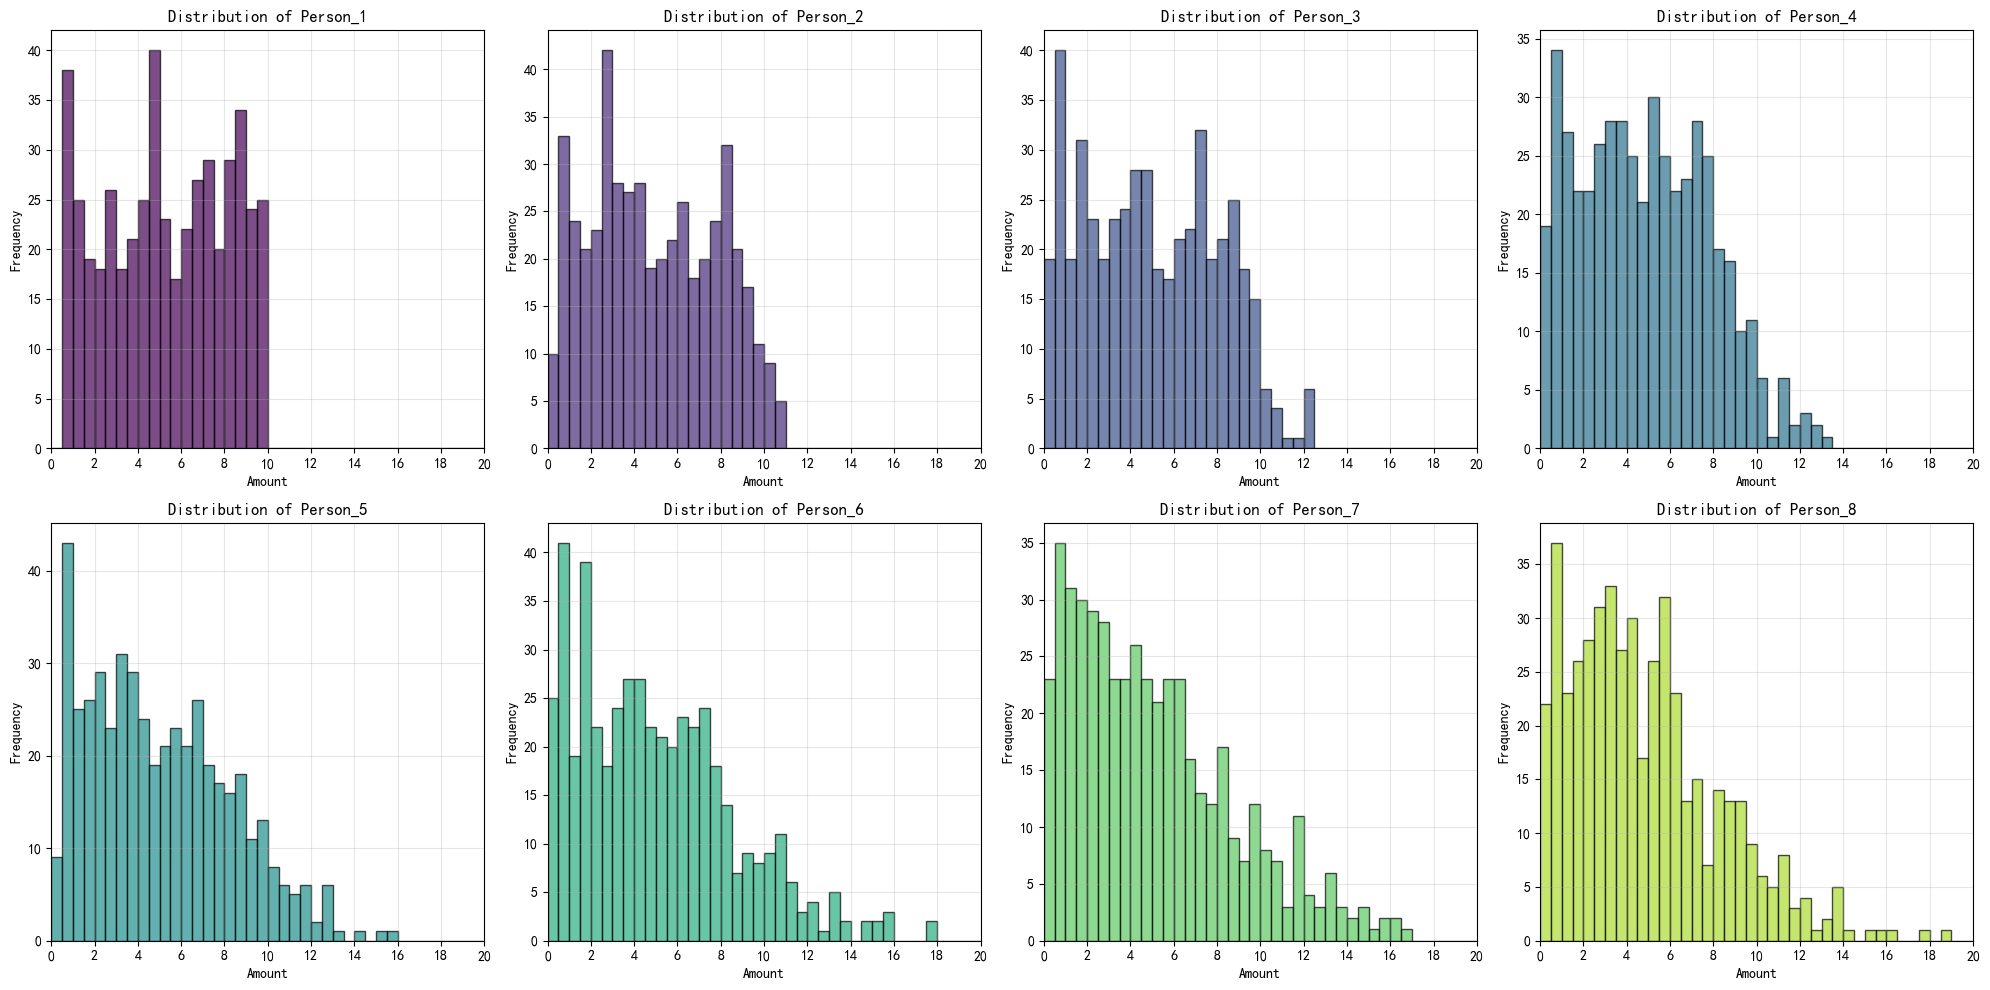

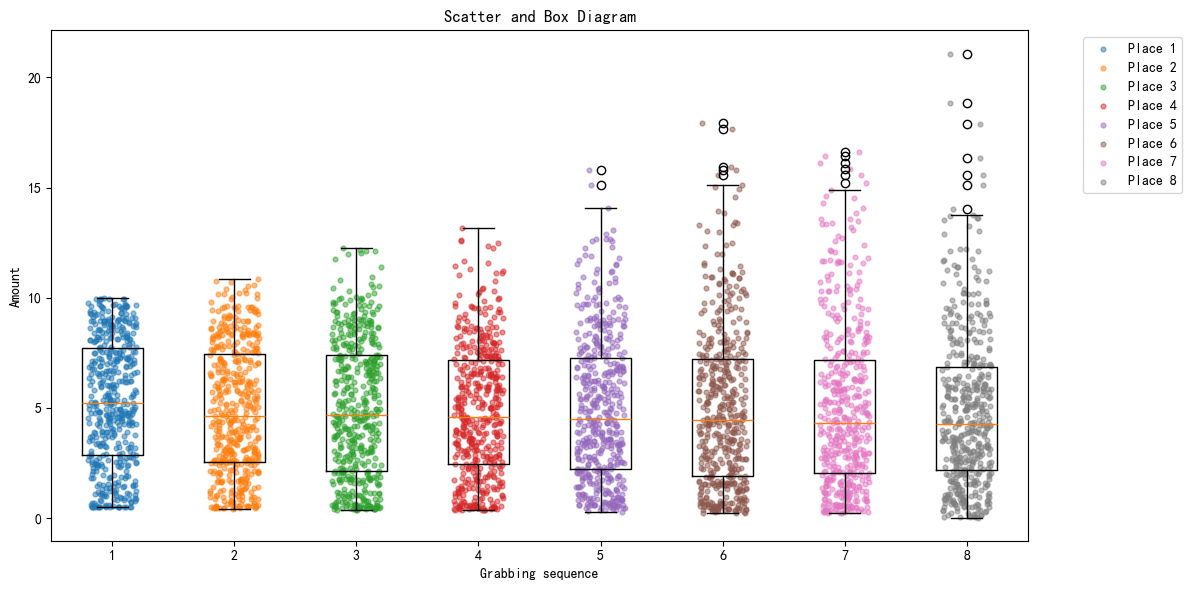

------------------------------
         Person_1    Person_2    Person_3    Person_4    Person_5    Person_6  \
count  480.000000  480.000000  480.000000  480.000000  480.000000  480.000000   
mean     5.292854    4.917792    4.973792    4.872021    5.019896    5.021417   
std      2.812736    2.855054    3.079805    2.965913    3.253246    3.595324   
min      0.500000    0.440000    0.380000    0.360000    0.300000    0.260000   
25%      2.870000    2.580000    2.165000    2.452500    2.247500    1.910000   
50%      5.225000    4.635000    4.710000    4.605000    4.515000    4.475000   
75%      7.737500    7.432500    7.402500    7.180000    7.285000    7.207500   
max      9.980000   10.860000   12.280000   13.190000   15.820000   17.920000   

         Person_7    Person_8  
count  480.000000  480.000000  
mean     5.038271    4.863958  
std      3.707104    3.512852  
min      0.230000    0.040000  
25%      2.047500    2.182500  
50%      4.340000    4.265000  
75%      7.1925

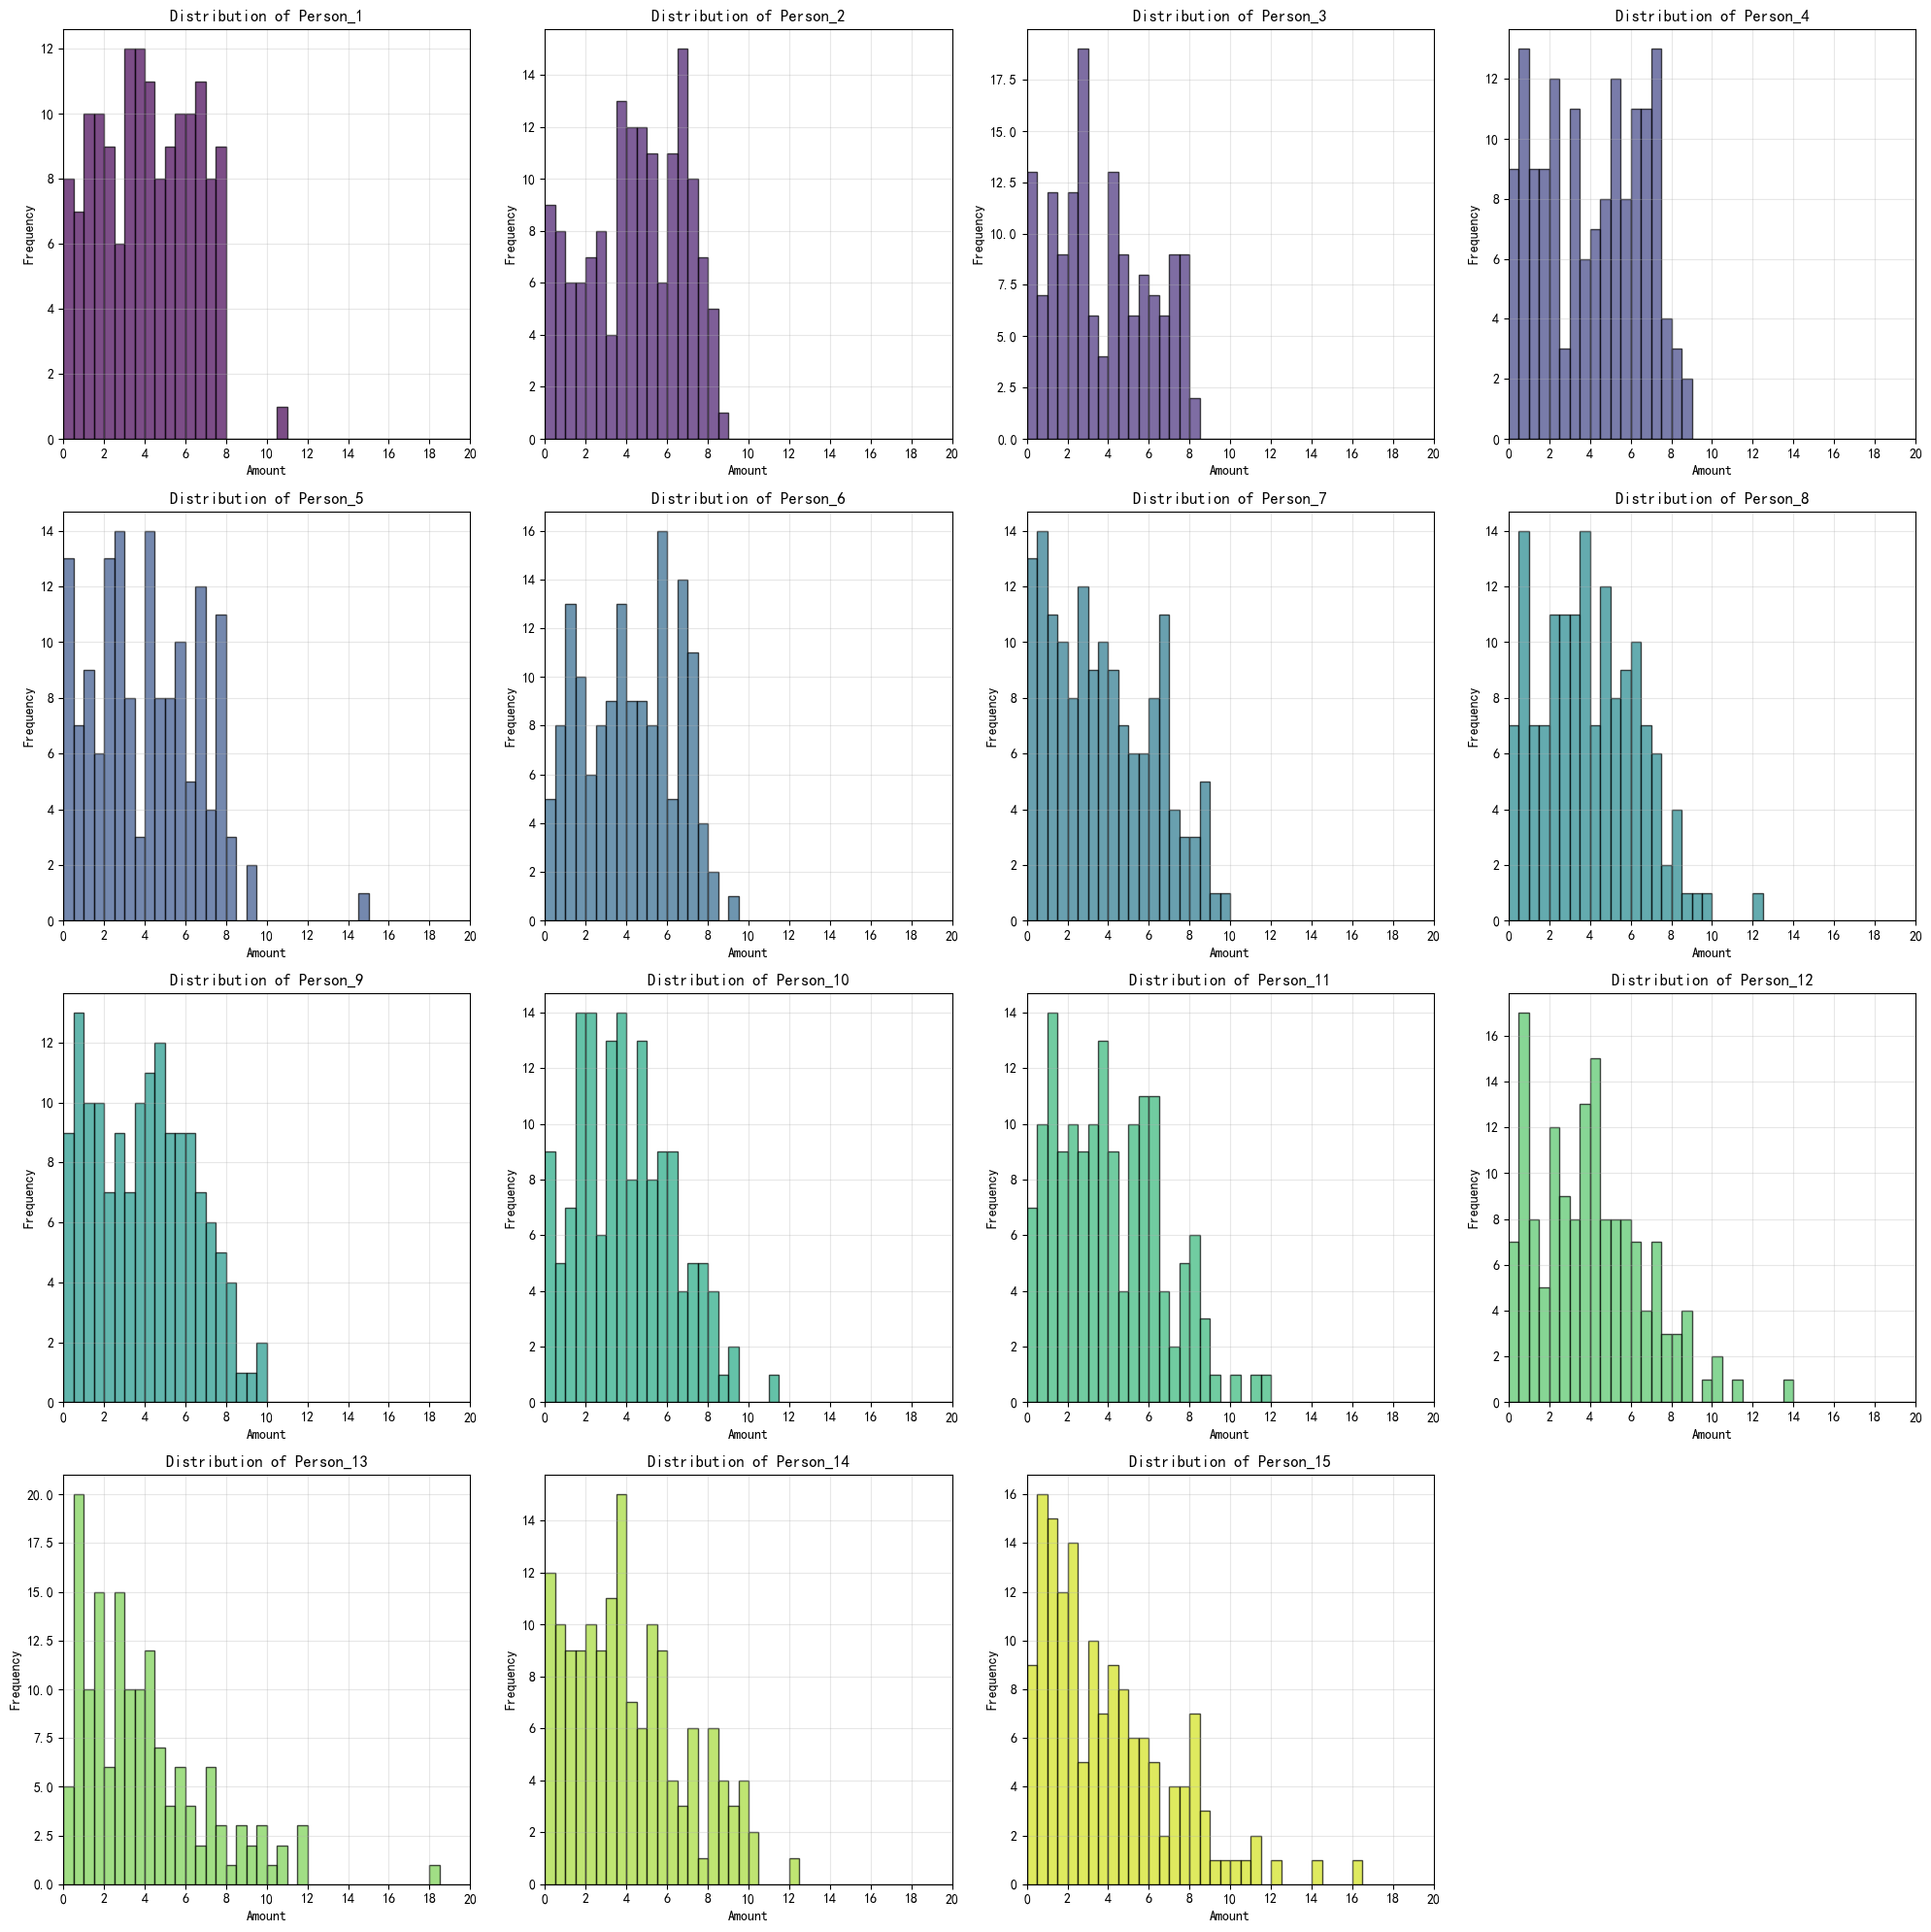

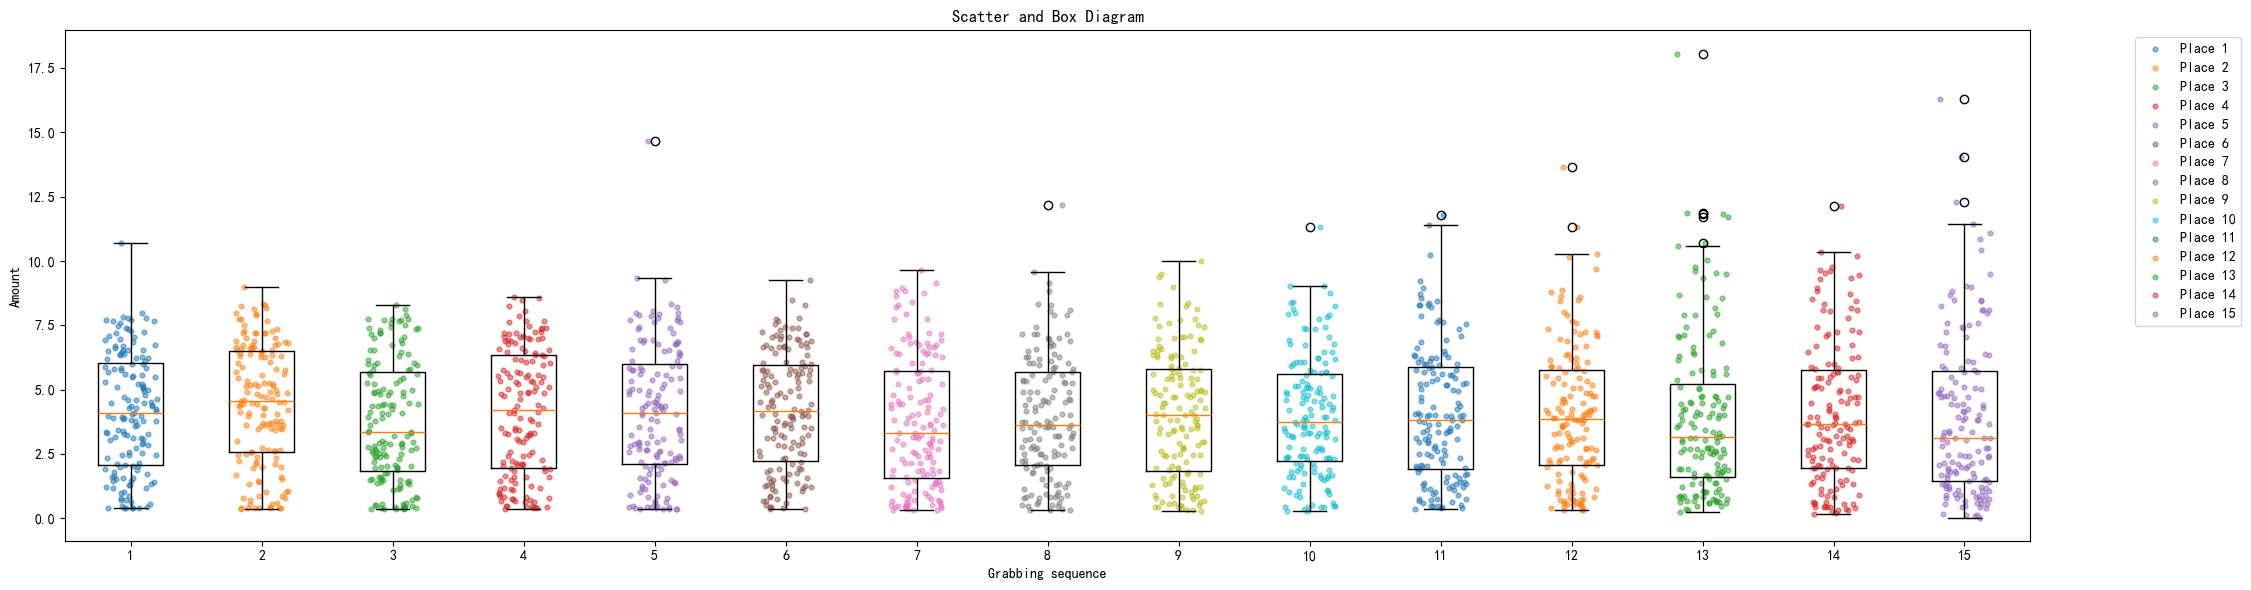

------------------------------
         Person_1    Person_2    Person_3    Person_4    Person_5    Person_6  \
count  151.000000  151.000000  151.000000  151.000000  151.000000  151.000000   
mean     4.130331    4.440530    3.758477    4.109536    4.107417    4.178344   
std      2.290365    2.335541    2.336849    2.441102    2.585145    2.248537   
min      0.400000    0.370000    0.360000    0.350000    0.340000    0.350000   
25%      2.075000    2.565000    1.815000    1.930000    2.105000    2.235000   
50%      4.070000    4.550000    3.330000    4.200000    4.100000    4.170000   
75%      6.050000    6.515000    5.695000    6.325000    5.995000    5.950000   
max     10.710000    8.970000    8.270000    8.610000   14.680000    9.250000   

         Person_7    Person_8    Person_9   Person_10   Person_11   Person_12  \
count  151.000000  151.000000  151.000000  151.000000  151.000000  151.000000   
mean     3.746026    3.941060    3.997483    3.980927    4.052848    4.022848

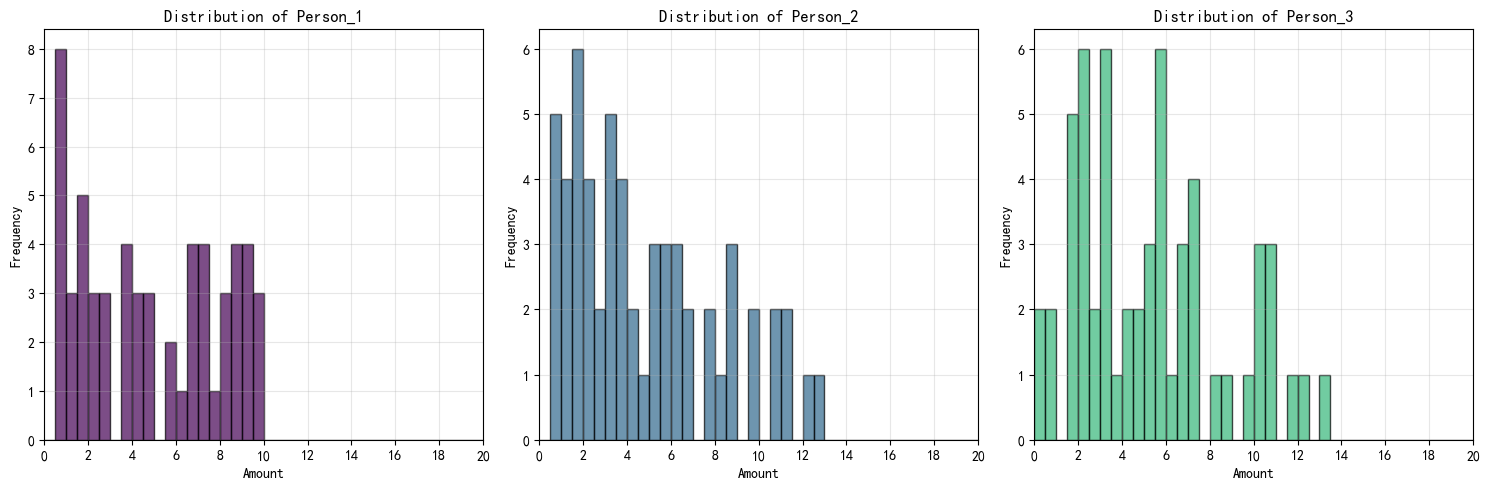

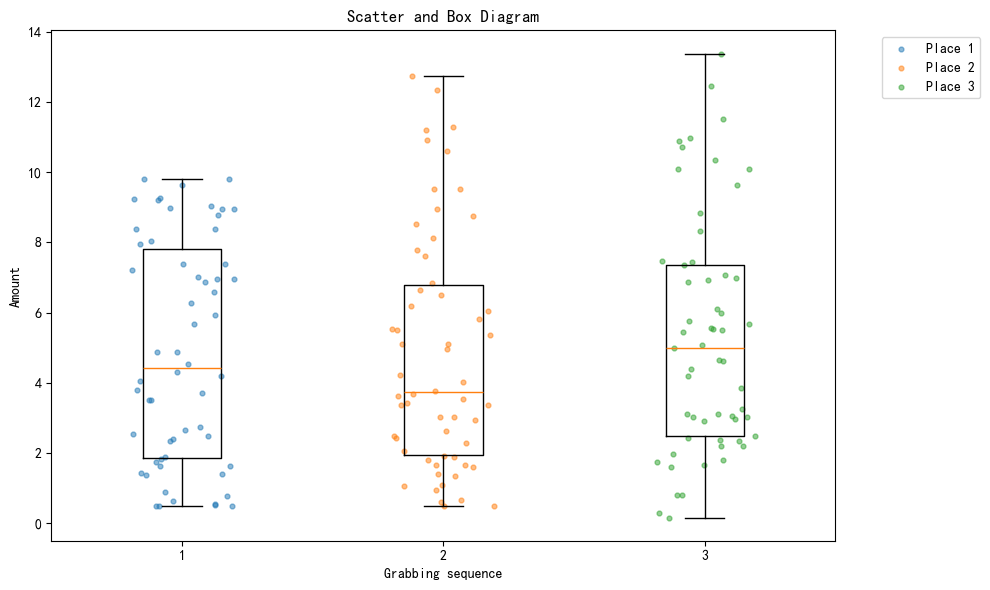

------------------------------
        Person_1   Person_2   Person_3
count  58.000000  58.000000  57.000000
mean    4.877241   4.825517   5.331579
std     3.159799   3.391713   3.379243
min     0.500000   0.500000   0.160000
25%     1.852500   1.937500   2.470000
50%     4.425000   3.730000   5.000000
75%     7.800000   6.797500   7.360000
max     9.810000  12.750000  13.380000
------------------------------


In [2]:
analyze_distribution("data/database_C.csv")
analyze_distribution("data/database_A.csv")
analyze_distribution("data/database_B.csv")

Among these, **Dataset A** and **Dataset B** had smaller sample sizes and lacked significant statistical meaning, so we used them only as validation sets. Subsequent data processing and analysis mainly focused on **Dataset C**. 

### 1.3 Data Analysis and Feature Extraction

Through in-depth analysis of 480 sets of random red envelope data with 8 participants per set and a total amount of 40 yuan, we have drawn the following superficial conclusions from three dimensions: statistical measures, distribution evolution, and sequence correlation:

#### 1.3.1 Stability of Expected Value and "Fairness"
From the **Summary Statistics**, it can be seen that the average amount for all participants is highly concentrated around 5.00 yuan (theoretical expected value 40/8 = 5.0).
*   **The mean value exhibits Homogeneity**: The means for Person_1 to Person_8 deviate very little (between 4.85 ~ 5.27), indicating that from a long-term observation perspective, the red envelope algorithm is fair to participants in all positions in terms of "expected returns".
*   **First-mover Uniform Effect**: Person_1 has the highest mean (5.27), and their histogram exhibits characteristics closer to a uniform distribution. This indicates that the first recipient may have some form of "protection mechanism" or different sampling interval definition.

#### 1.3.2 Position Determines "Luck" Ceiling
Observing **the Scatter and Box Diagram** and standard deviation (std) data, there is a clear characteristic of **sequential risk increase**:
*   **Evolution of Standard Deviation**：Standard deviation gradually expands from 2.81 for Person_1 to 3.71 for Person_7. The length of the "whiskers" in the box plots and the range of outliers significantly extend toward higher values as the sequence number increases.
*   **Early Recipients**(positions 1-3) face severe restrictions; Person_1's maximum value is only 9.98, almost confined within twice the average value.
*   **Late Recipients**(positions 6-8) have extremely high chances of large amounts; Person_8 drew the highest value in the entire sample of 21.08 (more than half of the total amount).

#### 1.3.3 Morphological Evolution of Probability Density Distribution 
Analyzing **the Distribution Histogram**for each member, the distribution pattern of red envelope amounts undergoes fundamental transformation with the sequence:
*   **From "Rectangle" to "Decay"**：
    *   **Person_1** exhibits a typical **truncated uniform distribution**, with amounts densely distributed between 0 ~ 10, showing strong boundary characteristics.
    *   As the sequence moves forward, the distribution gradually shifts leftward and develops a long tail. The distributions of **Person_7** and **Person_8** have evolved into obvious **exponential decay or three-segment decay patterns**, where most observations are compressed in the small amount interval of 0 ~ 5, while the tail portion extends to 15 ~ 20 yuan.

#### 1.3.4 Summary
This dataset clearly reveals that red envelope distribution is not simply globally random, but rather a sequential random process with Markov chain characteristics. While the position number does not change the expected return, it profoundly affects the risk distribution pattern.



A basic strategy is that although average returns are equal, the later you grab, the higher the risk (variance). If you pursue stability, grab early; if you seek the ultimate thrill of "best luck", grabbing later is more likely to create surprises.

### 2. Model Construction
All models in this chapter use the Kolmogorov-Smirnov test combined with Monte Carlo simulation. Traditional K-S testing using lookup tables typically requires that the parameters of the distribution are known in advance. However, in this study, the model parameters are obtained through Maximum Likelihood Estimation (MLE) or other optimization algorithms based on sample data. This practice of "fitting parameters and conducting tests using the same dataset" makes the p-values from the standard K-S test overly optimistic. Therefore, we introduced 5000 Monte Carlo simulations. Based on the fitted model parameters, we randomly generated 5000 sets of simulated data of equivalent scale. We calculated the maximum distance (D-statistic) between each set of simulated data and the theoretical model, thereby constructing an empirical distribution of the D-statistic under this model and correcting the p-value.

#### 2.0 Model Assumption

- Under the conditions of fixed total red packet amount and number of participants, all participating users are treated as homogeneous individuals in the red packet allocation mechanism. That is, for any fixed collection position k, the red packet amounts received by different users follow the same conditional distribution, without introducing individual-level bias parameters.
- It is assumed that the red packet allocation algorithm remains unchanged within the research time window. Collection time (such as holidays versus workdays, day-night differences) does not affect the red packet generation mechanism; it may only affect participation behavior, which is not modeled at the behavioral level in this paper.
- Total red packet amount and number of participants serve only as parameter inputs for the allocation mechanism. The functional form of the mechanism remains consistent across different amounts and participant numbers, without structural changes based on specific values.
- Given the red packet parameters (total amount, number of participants) and allocation mechanism, the allocation results between different red packet experiments are independent. This paper does not consider cross-red packet correlations introduced by factors such as social network structure and user re-participation.

#### 2.1 Model Hypothesis One: Uniform Distribution

##### 2.1.1 Model Description

Considering the fairness of red packet grabbing and the simplicity of the mechanism, we first consider modeling using a uniform distribution.

##### 2.1.2 Data Fitting
If we assume that the red envelope amount follows a uniform distribution, then its probability density function is:

$$ f(x|a,b) = \begin{cases} \frac{1}{b-a} & \text{if } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases} $$

Where:

- $a$ is the lower bound of the distribution (minimum red envelope amount)
- $b$ is the upper bound of the distribution (maximum red envelope amount)

The following is the derivation process for the maximum likelihood estimation of parameters $a$ and $b$ for the uniform distribution

**1. Likelihood Function**

Assuming we have a set of independent and identically distributed red envelope sample data: $x_1, x_2, ..., x_n$. The probability density function of the uniform distribution is: 
$$f(x|a, b) = \begin{cases} \frac{1}{b-a} & a \le x \le b \\ 0 & \text{其他} \end{cases}$$

The likelihood function $L(a, b)$ is the product of all sample probability densities: 
$$L(a, b) = \prod_{i=1}^{n} f(x_i|a, b)$$

**2. Introducing Constraints**

Only when **all sample points** $x_i$ are within the interval $[a, b]$ will the likelihood function be non-zero. In other words, the following must be satisfied:
*   $a \le x_1, x_2, ..., x_n$ (i.e., $a \le$ minimum value in the sample)
*   $b \ge x_1, x_2, ..., x_n$ (i.e., $b \ge$ maximum value in the sample)

Under these constraints, the likelihood function can be written as:
$$L(a, b) = \left( \frac{1}{b-a} \right)^n$$

**3. Maximizing the Likelihood Function**

*   Observing$L(a, b) = \frac{1}{(b-a)^n}$。
*   To make this fraction **maximum**, the denominator $(b-a)^n$ must be **minimum**.
*   To minimize $(b-a)$, i.e., to make the interval length as short as possible.

**4. Determining Estimated Values**

Subject to the constraints in Step 2:
1.  **Regarding $a$：** $a$ must be less than or equal to all sample values. To minimize $b-a$, $a$ should take the **largest possible** value. Therefore, the maximum possible value of $a$ is the minimum value in the sample:
    $$\hat{a} = \min(x_1, x_2, ..., x_n)$$

2.  **Regarding $b$：** $b$ must be greater than or equal to all sample values. To minimize $b-a$, $b$ should take **the smallest possible** value. Therefore, the minimum possible value of $b$ is the maximum value in the sample: 
    $$\hat{b} = \max(x_1, x_2, ..., x_n)$$



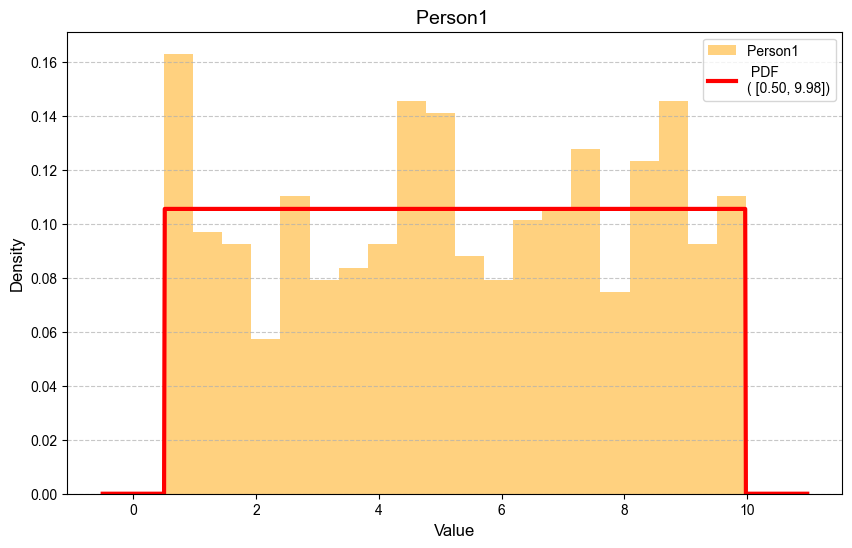

result:
min (a): 0.5000
max (b): 9.9800
interval (b-a): 9.4800


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!python -m pip install scipy
from scipy.stats import uniform

df = pd.read_csv("data/database_C.csv")
df_clean = df.iloc[:-1].copy()

person1_values = df_clean['Person1'].astype(float)

a_fit, scale_fit = uniform.fit(person1_values)
b_fit = a_fit + scale_fit

plt.figure(figsize=(10, 6))

plt.hist(person1_values, bins=20, density=True, alpha=0.5, color='orange', label='Person1 ')

x = np.linspace(a_fit - 1, b_fit + 1, 1000)
pdf = uniform.pdf(x, loc=a_fit, scale=scale_fit)
plt.plot(x, pdf, 'r-', lw=3, label=f' PDF\n( [{a_fit:.2f}, {b_fit:.2f}])')

plt.title('Person1 ', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print(f"result:")
print(f"min (a): {a_fit:.4f}")
print(f"max (b): {b_fit:.4f}")
print(f"interval (b-a): {scale_fit:.4f}")


The final fitting result can be expressed as:

$$ X_1 \sim Uniform(0.5, 9.98) $$


##### 2.1.3 Kolmogorov-Smirnov test

Executing Monte Carlo Simulation (5000 iterations)...


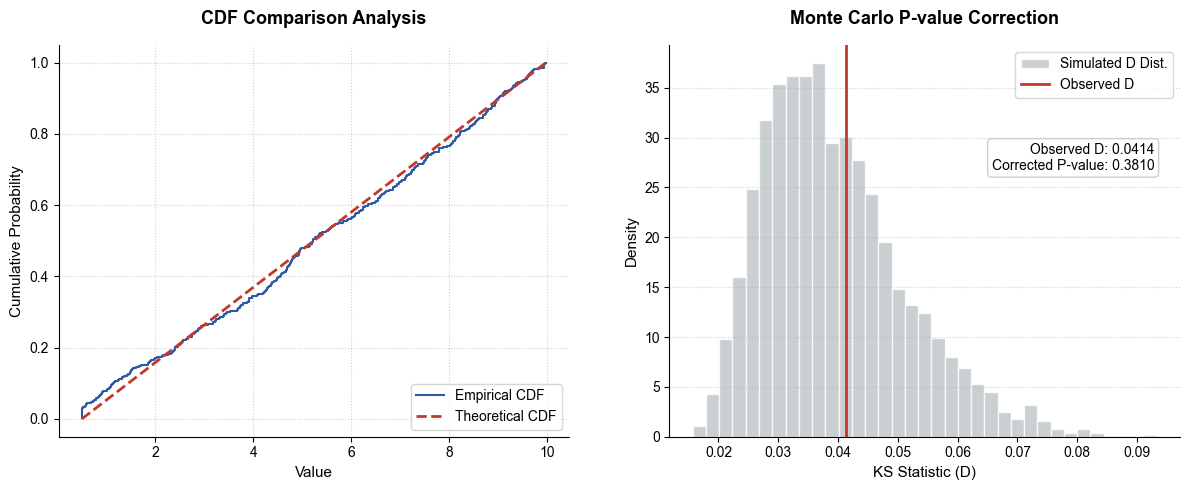

Fit Results: a=0.500, b=9.980
Corrected P-value: 0.3810


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, kstest
import io

df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person1'].astype(float).values
n_samples = len(person1_data)

a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(w_pad=4.0)
plt.show()

print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

We obtain $P > 0.5$, so we accept the uniform distribution model and its parameters; $X_1$ follows a uniform distribution.

However, we found that: the amounts received by subsequent individuals exhibit a clear tail effect. From the scatter plot, we can observe that samples from later individuals clearly spread toward larger amounts, with the tail end of the distribution showing a decreasing shape. At this point, continuing to use the uniform distribution model is clearly no longer appropriate. For example, let's analyze the sample for the third person:

Executing Monte Carlo Simulation (5000 iterations)...


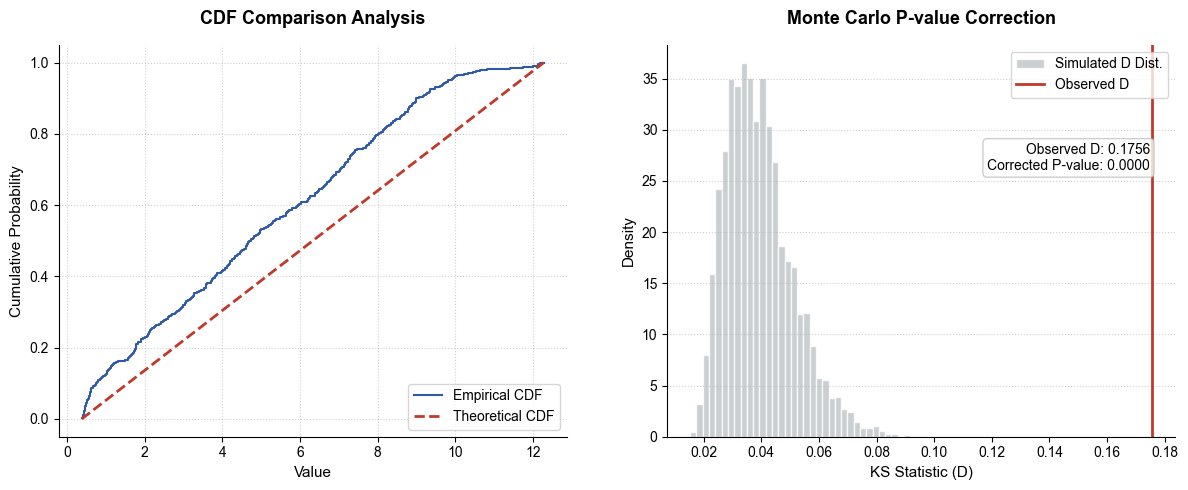

Fit Results: a=0.380, b=12.280
Corrected P-value: 0.0000


In [11]:

df_clean = df[df['Trial'] != 'Total'].copy()
person1_data = df_clean['Person3'].astype(float).values
n_samples = len(person1_data)

a_obs, scale_obs = uniform.fit(person1_data)
b_obs = a_obs + scale_obs
d_obs, _ = kstest(person1_data, 'uniform', args=(a_obs, scale_obs))

n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation ({n_sims} iterations)...")
for i in range(n_sims):
    sim_sample = uniform.rvs(loc=a_obs, scale=scale_obs, size=n_samples)
    a_sim, scale_sim = uniform.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'uniform', args=(a_sim, scale_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=100)

sorted_data = np.sort(person1_data)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_range = np.linspace(a_obs, b_obs, 200)
theoretical_cdf = uniform.cdf(x_range, loc=a_obs, scale=scale_obs)

ax1.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post', zorder=2)
ax1.plot(x_range, theoretical_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2, zorder=3)

ax1.set_title('CDF Comparison Analysis', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=11)
ax1.set_ylabel('Cumulative Probability', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax2.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label=f'Observed D')

ax2.set_title('Monte Carlo P-value Correction', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('KS Statistic (D)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

text_str = f'Observed D: {d_obs:.4f}\nCorrected P-value: {p_corrected:.4f}'
ax2.text(0.95, 0.75, text_str, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax2.legend(loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(w_pad=4.0)
plt.show()

print(f"Fit Results: a={a_obs:.3f}, b={b_obs:.3f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.1.4 Conclusion
$X_1$ follows a uniform distribution, while $X_i$ ($i>2$) does not follow a uniform distribution. A simple uniform distribution is insufficient to describe the probability model for any arbitrary $X_i$.


#### 2.2 Model Hypothesis 2: Normal Distribution

##### 2.2.1 Model Description

Considering that in certain random allocation scenarios, data tends to cluster around an average level, with extremely high or extremely low amounts occurring less frequently (consistent with the intuitive understanding of the Central Limit Theorem), we further consider using the normal distribution (Gaussian distribution) for modeling.

##### 2.2.2 Data Fitting

If we assume that red envelope amounts follow a normal distribution, then its probability density function is:

$$f(x|\mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)$$

Where:

*   $\mu$ is the mean of the distribution (the central location of red envelope amounts)
*   $\sigma$ is the standard deviation of the distribution (reflecting the dispersion or volatility of red envelope amounts)

Below is the derivation process for maximum likelihood estimation of the normal distribution parameters $\mu$ and $\sigma$:

**1. Likelihood Function**

Assume we have a set of independent and identically distributed red envelope sample data: $x_1, x_2, \dots, x_n$. The probability density function of the normal distribution is:

$$f(x|\mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

The likelihood function $L(\mu, \sigma)$ is the product of all sample probability densities:

$$L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x_i-\mu)^2}{2\sigma^2} \right)$$

**2. Log-Likelihood Function**

To facilitate calculation, take the natural logarithm of the likelihood function $L(\mu, \sigma)$ to obtain the log-likelihood function $\ln L(\mu, \sigma)$. Through logarithmic properties, the product can be converted to a sum:

$$\ln L(\mu, \sigma) = \ln \left[ \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x_i-\mu)^2}{2\sigma^2} \right) \right]$$

Expanding and simplifying gives:

$$\ln L(\mu, \sigma) = -\frac{n}{2}\ln(2\pi) - n\ln\sigma - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2$$

**3. Take Partial Derivatives and Set Them Equal to Zero**

To find the parameter values that maximize the log-likelihood function, we take partial derivatives with respect to both $\mu$ and $\sigma$, and set the derivatives equal to zero:

**(1) Partial derivative with respect to $\mu$:**

$$\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0$$

**(2) Partial derivative with respect to $\sigma$:**

$$\frac{\partial \ln L}{\partial \sigma} = -\frac{n}{\sigma} + \frac{1}{\sigma^3} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

**4. Solve for Estimates**

Solving the above system of equations yields the maximum likelihood estimators for the parameters:

*   **Estimate of mean $\hat{\mu}$：**
     From partial derivative equation (1) we get $\sum x_i - n\mu = 0$, hence: $$\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{x}$$ which is the sample mean.

*   **Estimate of standard deviation $\hat{\sigma}$:**
   Substituting $\hat{\mu}$ into partial derivative equation (2) gives: $$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$ $$\hat{\sigma} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$ which is the sample standard deviation.

Executing Monte Carlo Simulation for Person3...


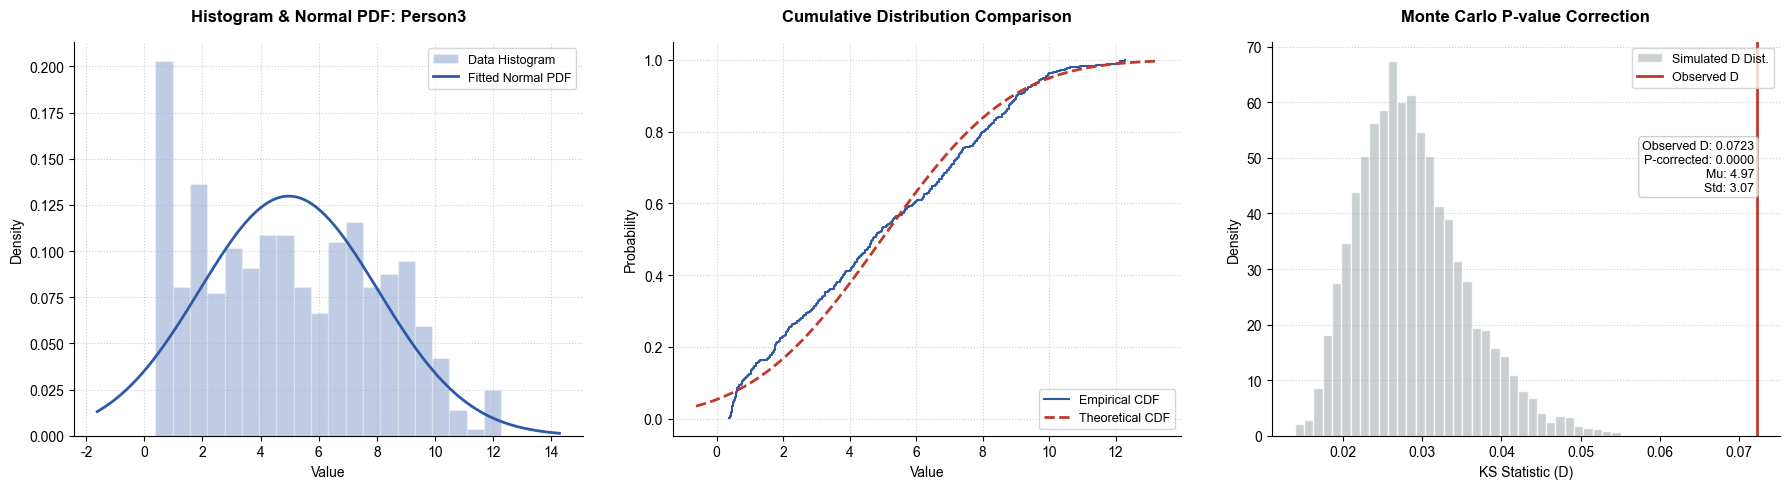

Results for Person3:
Normal Parameters: Mu=4.968, Std=3.075
KS Statistic D:    0.0723
Corrected P-value: 0.0000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kstest
import io
df = pd.read_csv('data/real_480.csv')
df_clean = df[df['Trial'] != 'Total'].copy()

target_person = 'Person3' 
data_values = df_clean[target_person].astype(float).values
n_samples = len(data_values)

mu_obs, std_obs = norm.fit(data_values)
d_obs, _ = kstest(data_values, 'norm', args=(mu_obs, std_obs))

n_sims = 5000
d_sims = np.zeros(n_sims)

print(f"Executing Monte Carlo Simulation for {target_person}...")
for i in range(n_sims):
    sim_sample = norm.rvs(loc=mu_obs, scale=std_obs, size=n_samples)
    mu_sim, std_sim = norm.fit(sim_sample)
    d_sim, _ = kstest(sim_sample, 'norm', args=(mu_sim, std_sim))
    d_sims[i] = d_sim

p_corrected = np.mean(d_sims >= d_obs)

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

ax1.hist(data_values, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
x_pdf = np.linspace(data_values.min() - 2, data_values.max() + 2, 200)
y_pdf = norm.pdf(x_pdf, mu_obs, std_obs)
ax1.plot(x_pdf, y_pdf, color='#2E59A7', lw=2, label='Fitted Normal PDF')

ax1.set_title(f'Histogram & Normal PDF: {target_person}', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Value', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

sorted_data = np.sort(data_values)
ecdf = np.arange(1, n_samples + 1) / n_samples
x_cdf = np.linspace(sorted_data.min() - 1, sorted_data.max() + 1, 200)
y_cdf = norm.cdf(x_cdf, loc=mu_obs, scale=std_obs)

ax2.step(sorted_data, ecdf, label='Empirical CDF', color='#2E59A7', lw=1.5, where='post')
ax2.plot(x_cdf, y_cdf, label='Theoretical CDF', color='#C0392B', linestyle='--', lw=2)

ax2.set_title('Cumulative Distribution Comparison', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Value', fontsize=10)
ax2.set_ylabel('Probability', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D Dist.')
ax3.axvline(d_obs, color='#C0392B', linestyle='-', linewidth=2, label='Observed D')

ax3.set_title('Monte Carlo P-value Correction', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('KS Statistic (D)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.grid(True, linestyle=':', alpha=0.6, axis='y')

text_str = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nMu: {mu_obs:.2f}\nStd: {std_obs:.2f}'
ax3.text(0.95, 0.75, text_str, transform=ax3.transAxes, fontsize=9,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#BDC3C7'))

ax3.legend(loc='upper right', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout(w_pad=3.0)
plt.show()

print(f"Results for {target_person}:")
print(f"Normal Parameters: Mu={mu_obs:.3f}, Std={std_obs:.3f}")
print(f"KS Statistic D:    {d_obs:.4f}")
print(f"Corrected P-value: {p_corrected:.4f}")

##### 2.2.3 Conclusion
It can be observed that the P-value remains very small, indicating that the data does not conform to a normal distribution.

#### 2.3 Model Hypothesis 3: Piecewise Model

##### Model Description

After trying several other models with unsatisfactory results, and considering the trend shown in the histogram of rapid decline followed by steady decline, we decided to use a piecewise mixed model: The model consists of three segments - the first segment is an exponential decay segment, the second segment is a uniform distribution segment, and the third segment is an exponential decay segment. See below for specific analytical expressions and parameter representations:

##### 1. Probability Density Function $f(x)$

$$
f(x|\theta) = 
\begin{cases} 
k \cdot e^{-\lambda_1(x - \tau_1)} & a \le x < \tau_1 & \text{(第一段：指数衰减)} \\
k & \tau_1 \le x \le \tau_2 & \text{(第二段：均匀平台)} \\
k \cdot e^{-\lambda_2(x - \tau_2)} & \tau_2 < x \le b & \text{(第三段：指数衰减)} \\
0 & \text{其他}
\end{cases}
$$

where $k$ is the normalization constant (i.e., platform height), determined by the total probability axiom $\int_a^b f(x)dx = 1$.

##### 2. Derivation of Normalization Constant $k$

Calculate the area of three segmented regions:
- **Area 1**: $\int_a^{\tau_1} k e^{\lambda_1(\tau_1 - x)} dx = k \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} \right]$
- **Area 2**: $\int_{\tau_1}^{\tau_2} k dx = k(\tau_2 - \tau_1)$
- **Area 3**: $\int_{\tau_2}^b k e^{-\lambda_2(x - \tau_2)} dx = k \left[ \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]$

Let the total area equal 1, solving for $k$:
$$k = \left[ \frac{e^{\lambda_1(\tau_1 - a)} - 1}{\lambda_1} + (\tau_2 - \tau_1) + \frac{1 - e^{-\lambda_2(b - \tau_2)}}{\lambda_2} \right]^{-1}$$

##### 3. Cumulative Distribution Function $F(x)$

$$
F(x) = 
\begin{cases} 
k \frac{e^{\lambda_1(\tau_1 - a)} - e^{\lambda_1(\tau_1 - x)}}{\lambda_1} & a \le x < \tau_1 \\
F(\tau_1) + k(x - \tau_1) & \tau_1 \le x \le \tau_2 \\
F(\tau_2) + k \frac{1 - e^{-\lambda_2(x - \tau_2)}}{\lambda_2} & \tau_2 < x \le b
\end{cases}
$$



The model contains the following 4 parameters to estimate (assuming boundaries $a, b$ are known):

1.  **$\tau_1$ (First turning point)**: The critical value where data transitions from initial decay to stable platform.

2.  **$\tau_2$ (Second turning point)**: The critical value where data transitions from stable platform to terminal decay. Requires $a < \tau_1 < \tau_2 < b$.
3.  **$\lambda_1$ (Initial decay rate)**: Controls the steepness of the initial segment's decline. When $\lambda_1 > 0$, the curve declines from left to right.
4.  **$\lambda_2$ (Terminal decay rate)**: Controls the steepness of the tail segment's decline. When $\lambda_2 > 0$, the curve declines from the platform to the right.

##### 2.3.2 Maximum Likelihood Estimation (MLE) Solution

Given a set of independent and identically distributed (i.i.d.) observation samples $x = {x_1, x_2, ..., x_n}$.

##### 1. Construct the likelihood function $L(\theta)$

$$L(\theta) = \prod_{i=1}^{n} f(x_i | \tau_1, \tau_2, \lambda_1, \lambda_2)$$

##### 2. Construct the log-likelihood function $\ell(\theta)$

To simplify calculations, take the logarithm: $$\ell(\theta) = \sum_{i=1}^{n} \ln f(x_i)$$

Classify and count according to which interval each $x_i$ falls into:
- Let $n_1, n_2, n_3$ be the number of samples falling into the three intervals respectively.
- Expand the logarithmic terms: $$\ell(\theta) = n \ln k + \sum_{x_i \in [a, \tau_1)} \lambda_1(\tau_1 - x_i) + \sum_{x_i \in (\tau_2, b]} -\lambda_2(x_i - \tau_2)$$

where $k$ is a complex function of all four parameters.

##### 3. Solve derivatives

Theoretically, we need to take partial derivatives with respect to each parameter and set them to 0:
- $\frac{\partial \ell}{\partial \lambda_1} = 0, \quad \frac{\partial \ell}{\partial \lambda_2} = 0$
- $\frac{\partial \ell}{\partial \tau_1} = 0, \quad \frac{\partial \ell}{\partial \tau_2} = 0$

**Note**: Due to the expression for $k$ containing exponential terms and the break points $\tau$ appearing in the indicator functions of summation limits, this system of equations has no closed-form solution.

##### 4. Numerical optimization algorithm procedure

In actual computation, we use the ` L-BFGS-B algorithm ` to maximize $\ell(\theta)$:

1.  **Constraints**：
    *   $a + \epsilon \le \tau_1 \le \tau_2 - \epsilon$
    *   $\tau_1 + \epsilon \le \tau_2 \le b - \epsilon$
    *   $\lambda_1, \lambda_2 > 0$
2.  **Objective function**：Minimize the negative log-likelihood function $-\ell(\theta)$.
3.  **Search process**：
    *   The algorithm searches in the four-dimensional space for $(\tau_1, \tau_2, \lambda_1, \lambda_2)$.
    *   Each iteration recalculates the normalization coefficient $k$ based on current parameters.
    *   Uses gradient descent or quasi-Newton methods to find the parameter combination that maximizes the probability of observing the sample.

##### 2.3.3 Data Fitting & Model Testing

Running Analysis for Person1...


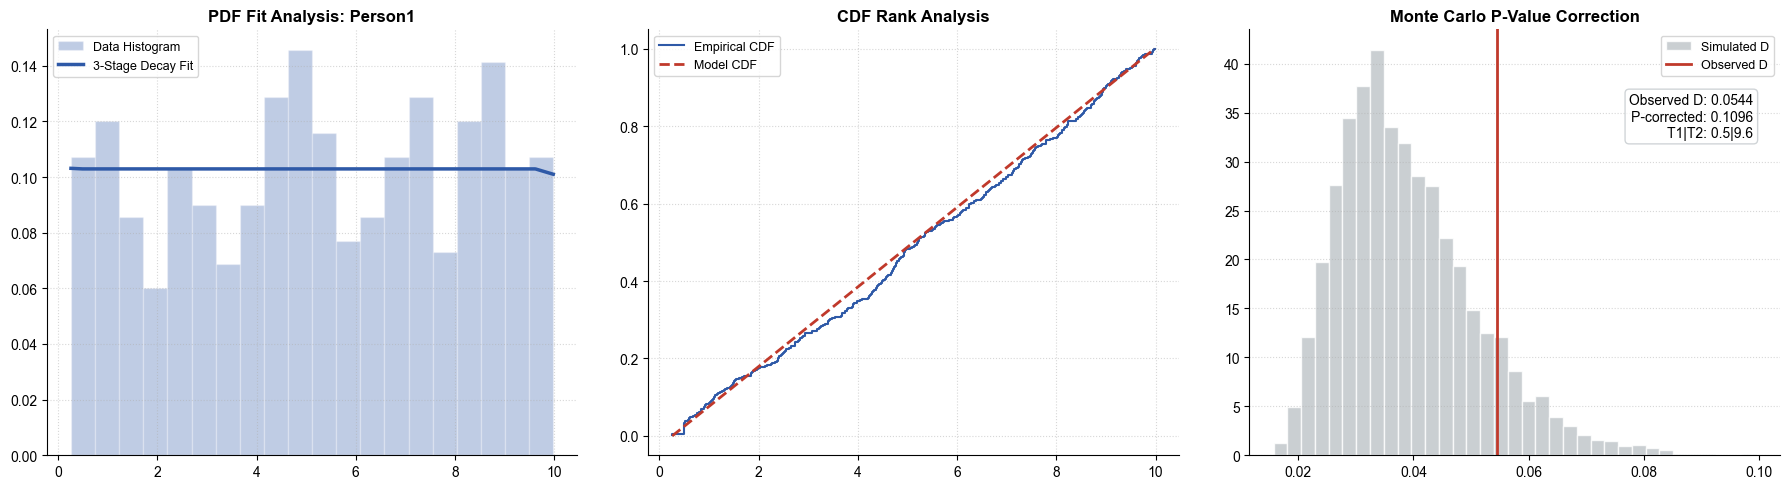

Analysis for Person1 completed. P-corrected: 0.1096


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest
import io
df = pd.read_csv('data/real_480.csv')
def analyze_person_distribution(person_num):

    target_col = f'Person{person_num}'
    df_clean = df[df['Trial'] != 'Total'].copy()
    data = df_clean[target_col].astype(float).values
    n_samples = len(data)
    v_min, v_max = data.min(), data.max()

    def get_params(t1, t2, l1, l2, a, b):
        area1 = (np.exp(l1 * (t1 - a)) - 1) / max(l1, 1e-10)
        area2 = t2 - t1
        area3 = (1 - np.exp(-l2 * (b - t2))) / max(l2, 1e-10)
        k = 1.0 / (area1 + area2 + area3)
        p1 = k * area1
        p2 = p1 + k * area2
        return k, p1, p2

    def pdf_func(x, t1, t2, l1, l2, a, b):
        k, _, _ = get_params(t1, t2, l1, l2, a, b)
        pdf = np.zeros_like(x)
        m1, m2, m3 = (x < t1), (x >= t1) & (x <= t2), (x > t2)
        pdf[m1] = k * np.exp(l1 * (t1 - x[m1]))
        pdf[m2] = k
        pdf[m3] = k * np.exp(-l2 * (x[m3] - t2))
        return pdf

    def cdf_func(x, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        cdf = np.zeros_like(x)
        m1 = (x >= a) & (x < t1)
        cdf[m1] = k * (np.exp(l1 * (t1 - a)) - np.exp(l1 * (t1 - x[m1]))) / max(l1, 1e-10)
        m2 = (x >= t1) & (x <= t2)
        cdf[m2] = p1 + k * (x[m2] - t1)
        m3 = (x > t2) & (x <= b)
        cdf[m3] = p2 + k * (1 - np.exp(-l2 * (x[m3] - t2))) / max(l2, 1e-10)
        cdf[x > b] = 1.0
        return np.clip(cdf, 0, 1)

    def rvs_func(size, t1, t2, l1, l2, a, b):
        k, p1, p2 = get_params(t1, t2, l1, l2, a, b)
        u = np.random.random(size)
        res = np.zeros(size)
        i1, i2, i3 = (u < p1), (u >= p1) & (u < p2), (u >= p2)
        res[i1] = t1 - np.log(np.exp(l1 * (t1 - a)) - u[i1] * l1 / k) / max(l1, 1e-10)
        res[i2] = t1 + (u[i2] - p1) / k
        res[i3] = t2 - np.log(1 - (u[i3] - p2) * l2 / k) / max(l2, 1e-10)
        return np.clip(res, a, b)

    def nll(p, obs):
        t1, t2, l1, l2 = p
        if t1 >= t2 or t1 <= v_min or t2 >= v_max or l1 <= 0 or l2 <= 0: return 1e12
        return -np.sum(np.log(pdf_func(obs, t1, t2, l1, l2, v_min, v_max) + 1e-12))


    bnds = [(v_min+0.2, v_max-0.2), (v_min+0.2, v_max-0.2), (0.01, 5), (0.01, 5)]
    res_obs = minimize(nll, x0=[v_min+1, v_max-1, 0.5, 0.5], args=(data,), bounds=bnds)
    t1_o, t2_o, l1_o, l2_o = res_obs.x
    
    d_obs = kstest(data, lambda x: cdf_func(x, t1_o, t2_o, l1_o, l2_o, v_min, v_max)).statistic

    n_sims = 5000
    d_sims = []
    print(f"Running Analysis for {target_col}...")
    for _ in range(n_sims):
        s_data = rvs_func(n_samples, t1_o, t2_o, l1_o, l2_o, v_min, v_max)
        s_res = minimize(nll, x0=[t1_o, t2_o, l1_o, l2_o], args=(s_data,), bounds=bnds, tol=1e-1)
        d_sims.append(kstest(s_data, lambda x: cdf_func(x, *s_res.x, v_min, v_max)).statistic)

    p_corrected = np.mean(np.array(d_sims) >= d_obs)

    plt.rcParams['font.sans-serif'] = ['Arial']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    x_grid = np.linspace(v_min, v_max, 500)

    ax1.hist(data, bins=20, density=True, color='#2E59A7', alpha=0.3, edgecolor='white', label='Data Histogram')
    ax1.plot(x_grid, pdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), color='#2E59A7', lw=2.5, label='3-Stage Decay Fit')
    ax1.set_title(f'PDF Fit Analysis: {target_col}', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, linestyle=':', alpha=0.5); ax1.spines[['top','right']].set_visible(False)

    ax2.step(np.sort(data), np.arange(1, n_samples+1)/n_samples, label='Empirical CDF', color='#2E59A7', lw=1.5)
    ax2.plot(x_grid, cdf_func(x_grid, t1_o, t2_o, l1_o, l2_o, v_min, v_max), label='Model CDF', color='#C0392B', ls='--', lw=2)
    ax2.set_title('CDF Rank Analysis', fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.5); ax2.spines[['top','right']].set_visible(False)

    ax3.hist(d_sims, bins=35, color='#BDC3C7', edgecolor='white', alpha=0.8, density=True, label='Simulated D')
    ax3.axvline(d_obs, color='#C0392B', lw=2, label='Observed D')
    ax3.set_title('Monte Carlo P-Value Correction', fontweight='bold')
    info = f'Observed D: {d_obs:.4f}\nP-corrected: {p_corrected:.4f}\nT1|T2: {t1_o:.1f}|{t2_o:.1f}'
    ax3.text(0.95, 0.85, info, transform=ax3.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='#BDC3C7'))
    ax3.legend(fontsize=9); ax3.grid(True, linestyle=':', alpha=0.5, axis='y'); ax3.spines[['top','right']].set_visible(False)

    plt.tight_layout(w_pad=3.0)
    plt.show()
    
    print(f"Analysis for {target_col} completed. P-corrected: {p_corrected:.4f}")


analyze_person_distribution(1)

Running Analysis for Person2...


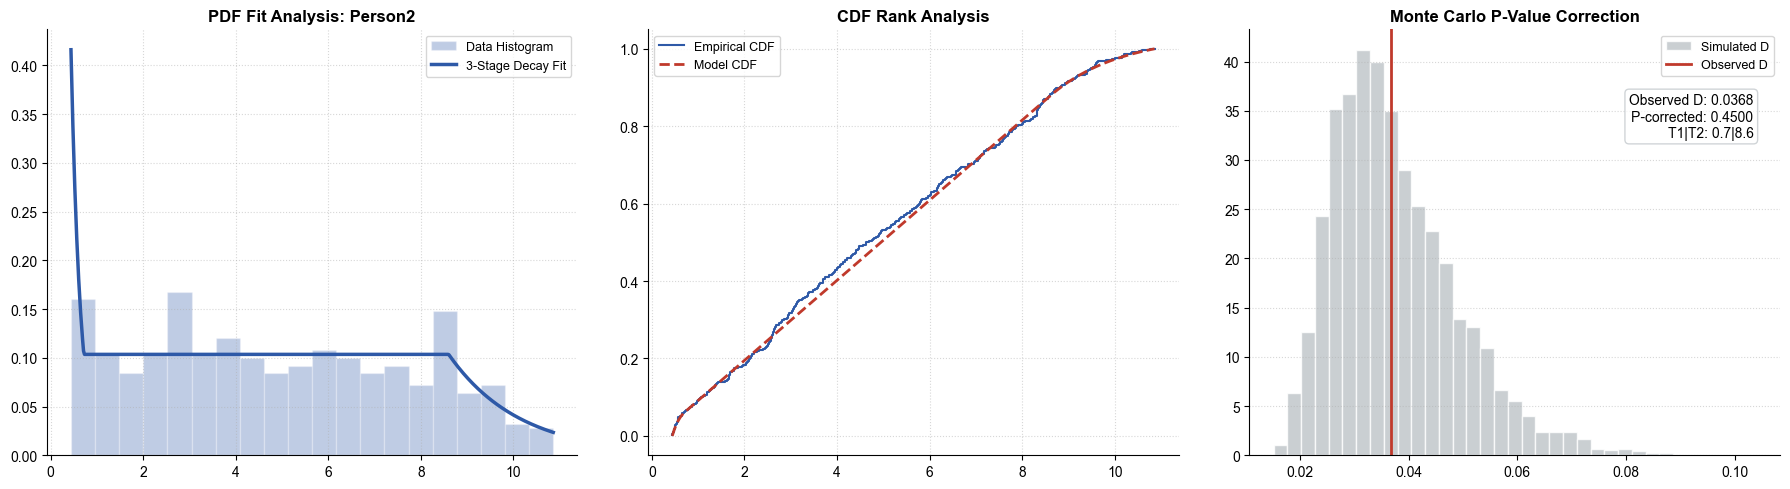

Analysis for Person2 completed. P-corrected: 0.4500


In [16]:
analyze_person_distribution(2)

Running Analysis for Person3...


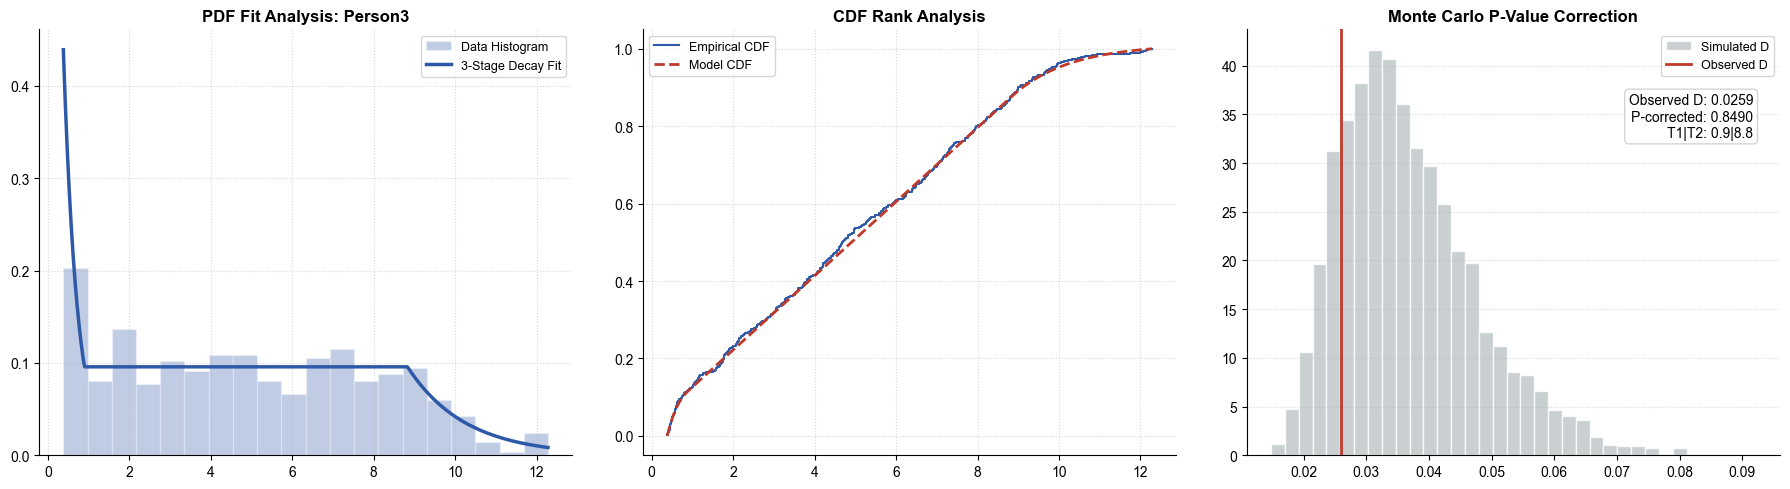

Analysis for Person3 completed. P-corrected: 0.8490


In [17]:
analyze_person_distribution(3)

Running Analysis for Person4...


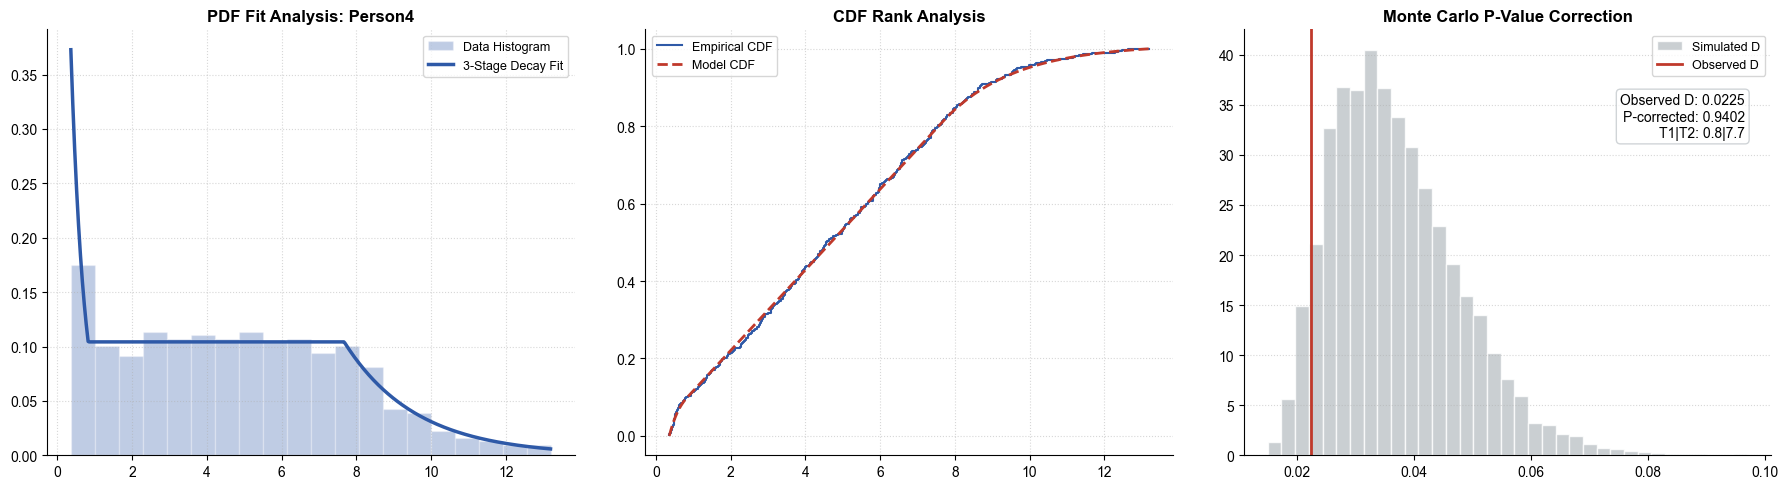

Analysis for Person4 completed. P-corrected: 0.9402


In [18]:
analyze_person_distribution(4)

Running Analysis for Person5...


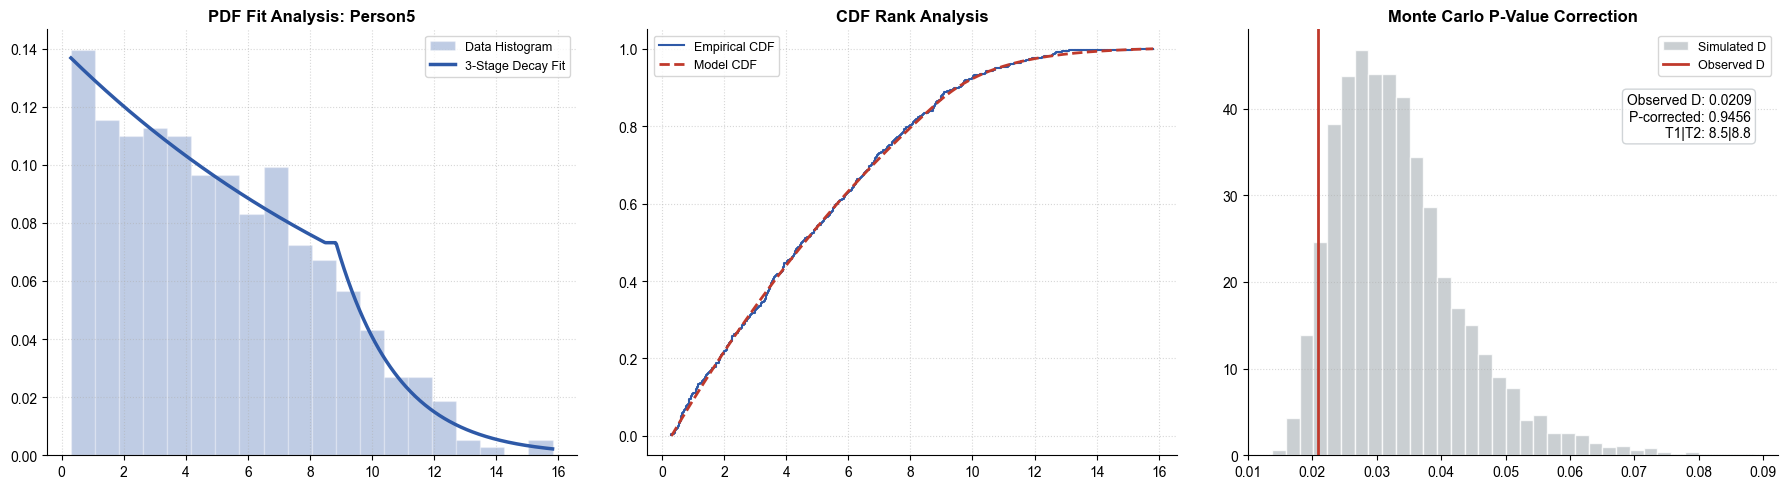

Analysis for Person5 completed. P-corrected: 0.9456


In [19]:
analyze_person_distribution(5)

Running Analysis for Person6...


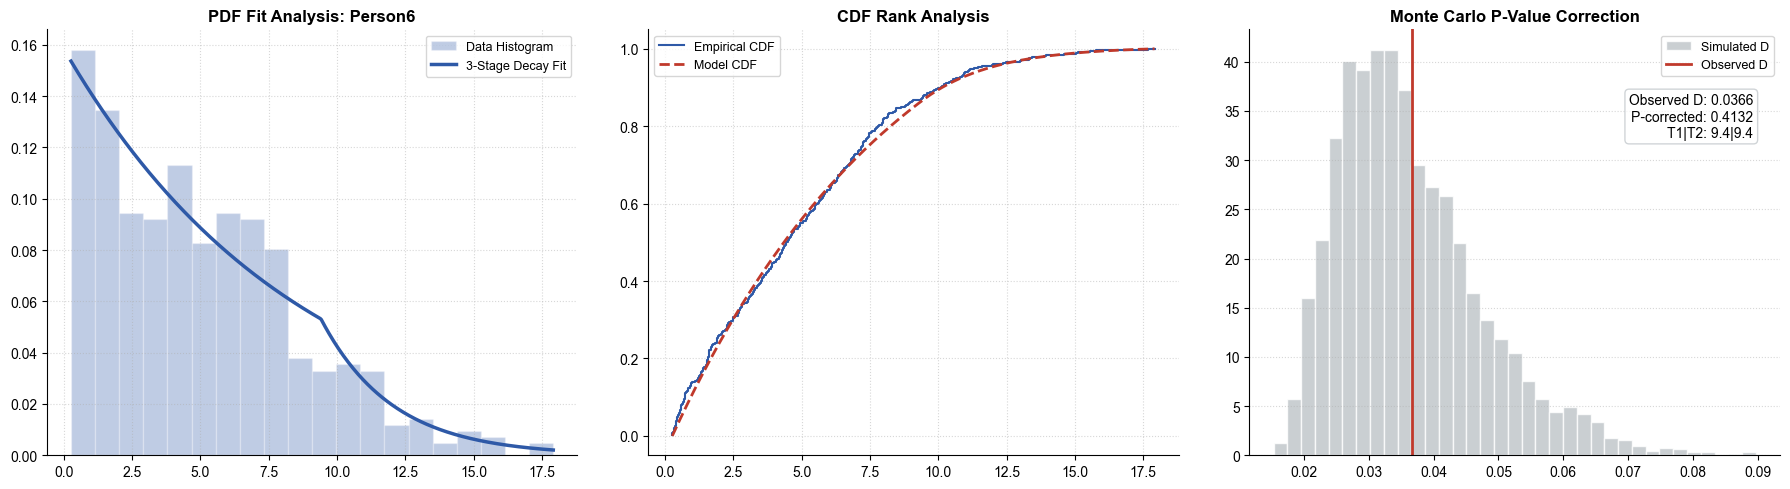

Analysis for Person6 completed. P-corrected: 0.4132


In [20]:
analyze_person_distribution(6)

Running Analysis for Person7...


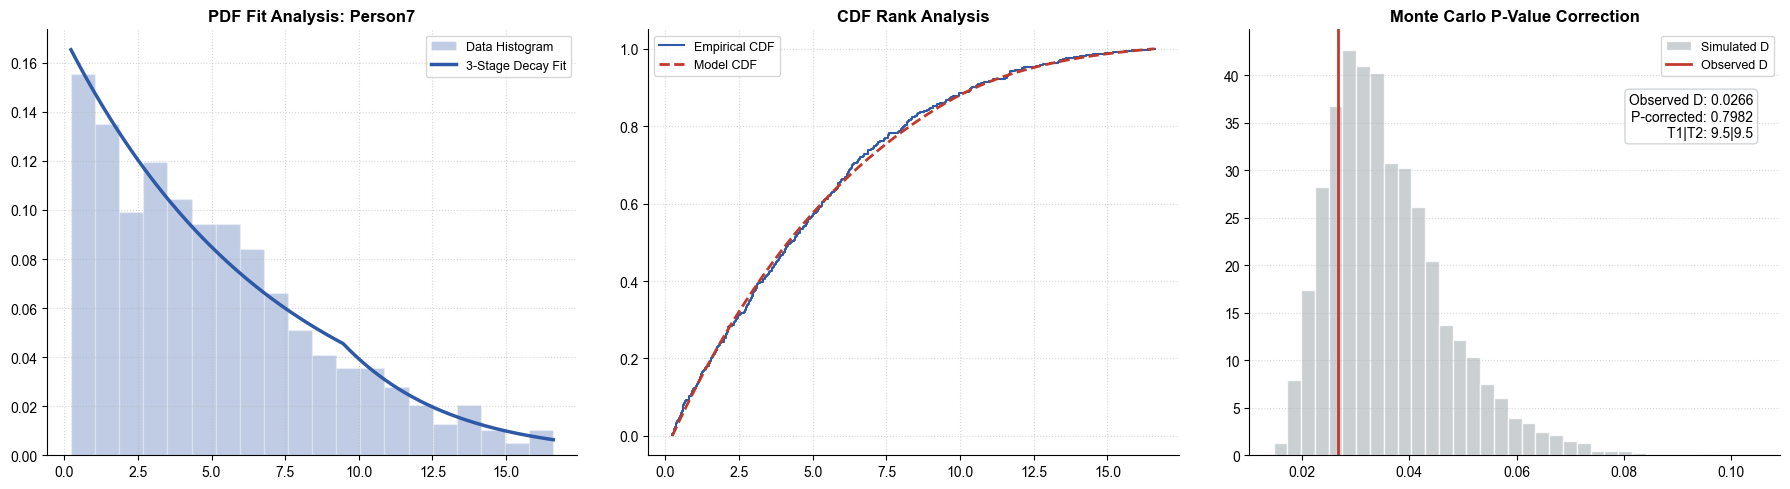

Analysis for Person7 completed. P-corrected: 0.7982


In [21]:
analyze_person_distribution(7)

Running Analysis for Person8...


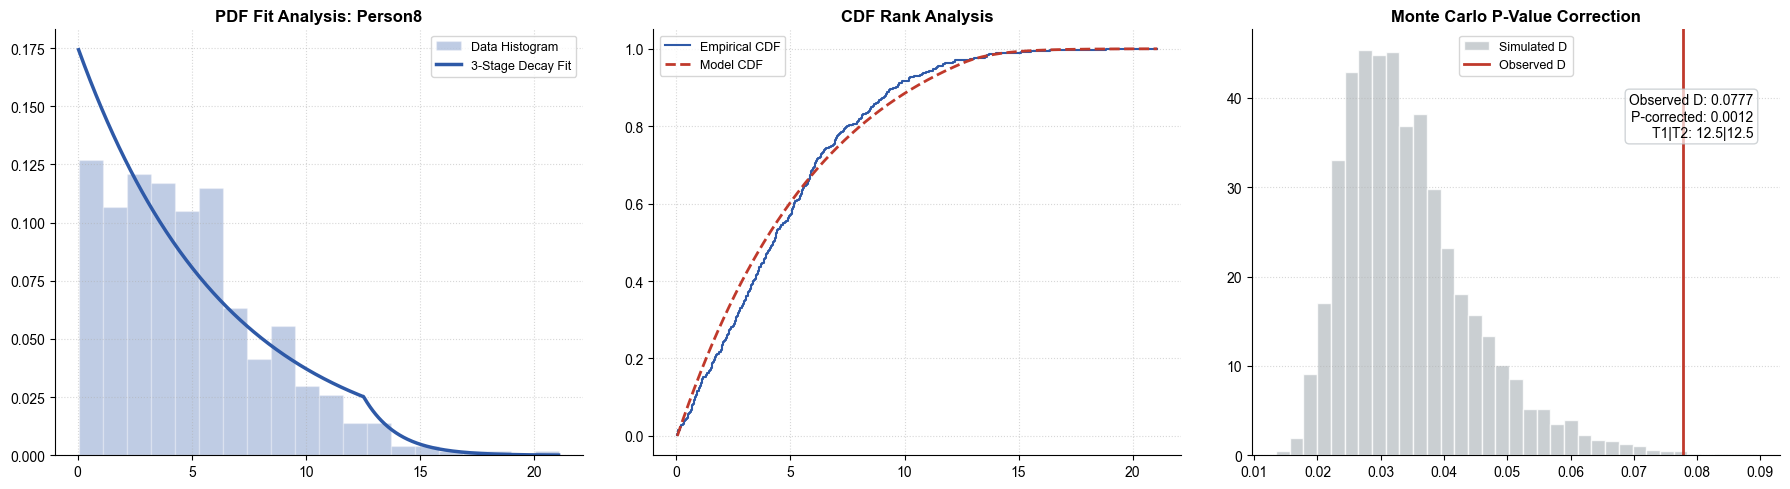

Analysis for Person8 completed. P-corrected: 0.0012


In [22]:
analyze_person_distribution(8)

##### 2.3.4 Conclusion
According to the P-values, the three-segment model provides an excellent fit for $X_i$ (where $1 < i < 7$). As $i$ increases, the uniform distribution interval shrinks to zero, and the entire distribution of $X_i$ approximates an exponential distribution. However, the distribution for the last person cannot be fitted by the three-segment model.

This discrepancy does not indicate an error in the three-segment model. The deviation in $X_n$ arises due to a loss of degrees of freedom. Since the total amount is fixed, the amount for the last person is determined by: $X_8 = S - \sum_{i=1}^{7} X_i$。This implies that Person 8 exhibits **no independent distribution pattern**. They are not generated by a specific "allocation logic" but rather emerge as the residual amount left after the first 7 individuals have drawn their shares.

#### 3. Deriving General Conclusions

Based on the analysis of data and model validation from the previous chapter, we have discovered the following patterns:
1.  **Minimum Guarantee Mechanism**：Person_8's minimum value was only $0.04$, while Person_1's minimum was $0.26$. The data supports the hypothesis of "existing minimum guaranteed amount". The high frequency of small amounts (approximately $0.5$ yuan) observed at Person_1 may not represent a global minimum guarantee, but rather is determined by the lower bound of the first sampling interval.
2.  **Dynamic Interval Scaling**：The median in the box plots (orange line) slightly decreases with sequence position, while the upper quartile and extreme values increase. This aligns with: each person's extraction upper limit being constrained by 2 times the current remaining average. As random fluctuations occur among earlier participants, the fluctuation in remaining space gets amplified through each layer, causing severe oscillations in the value range for later participants.

##### 3.1 Establishing the Double-Mean Method

Although we have now obtained a feasible probabilistic model through data fitting, due to the lack of more universally applicable conclusions, the guiding effect of this model on real life is limited. Therefore, we hope to obtain more general mathematical conclusions through further analysis of existing data.

During the process of hypothesizing models mentioned above, we found that $X_1$ can follow a uniform distribution well, while as $i$ increases, the uniform distribution part gradually becomes smaller. Therefore, we guess that $X_i$ may follow a conditional uniform distribution. Meanwhile, upon further observation of the $X_1$ data, we found that the maximum value of $x_1$ does not exceed 10, which is two times the average value.

In summary, we propose a possible WeChat red envelope mechanism: the "Double-Mean Method", which states: For the $i$-th person grabbing the red envelope, we assume that the remaining amount before they grab is $R_i$, the remaining number of people is $k$, and the amount they receive is $X_i$. Then, $$X_i \sim Uni(0.1\frac{R_i}{k}, 2\frac{R_i}{k})$$ This process is **a Markov chain**.

#### 3.2 Model Testing
First, normalize the raw data of the amount grabbed in each round to its proportion of the remaining total amount.

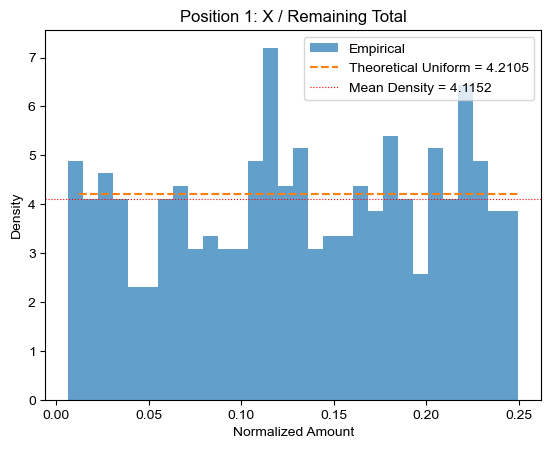

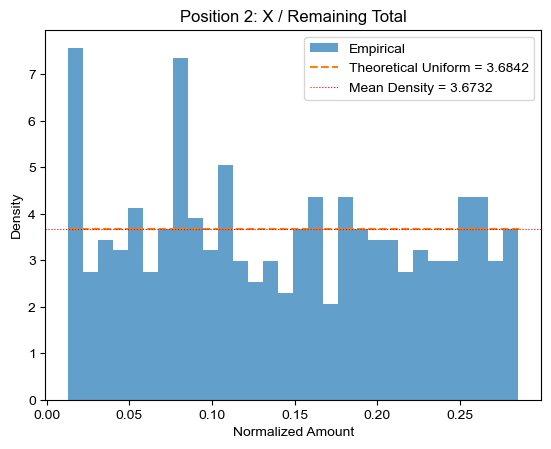

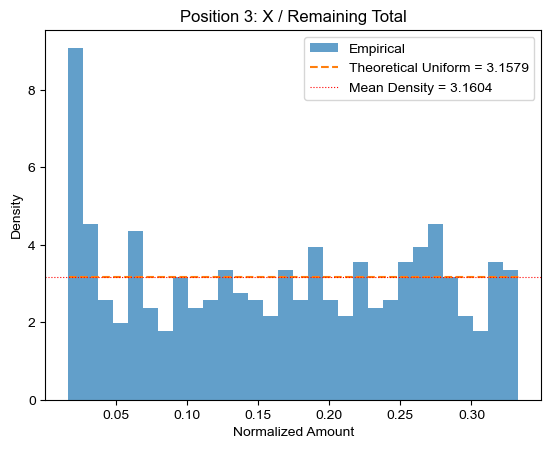

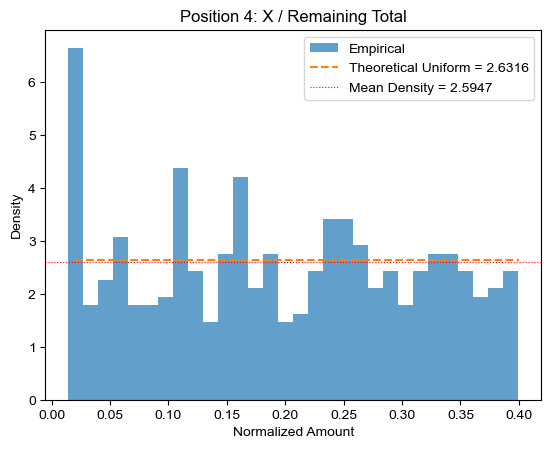

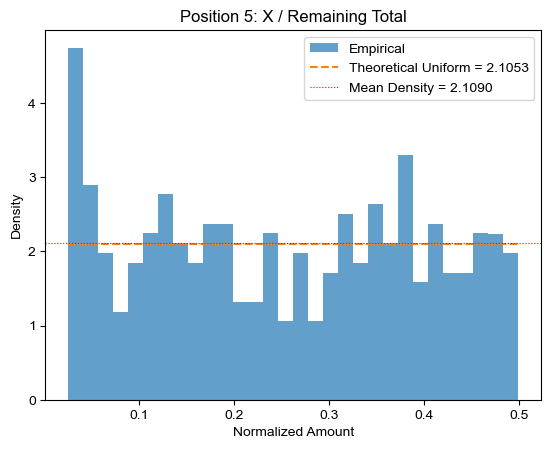

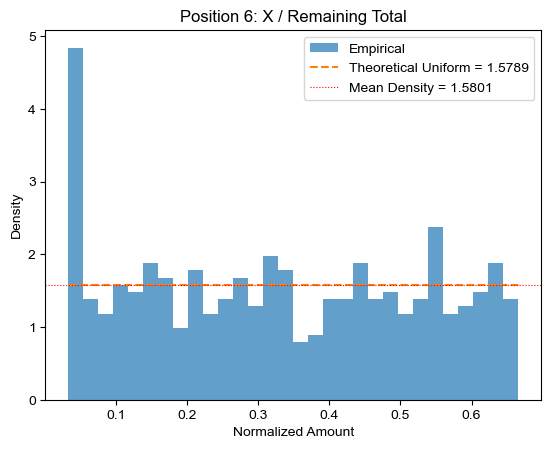

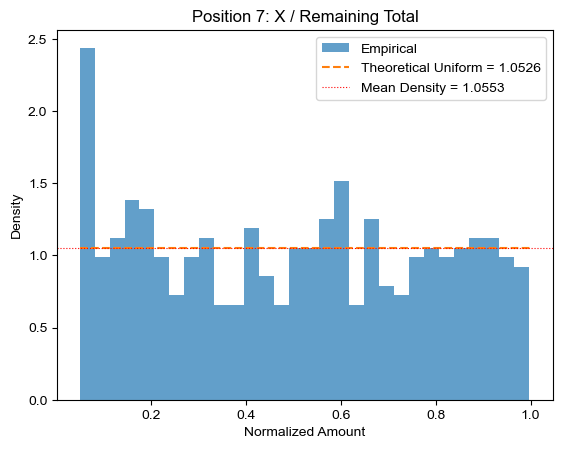

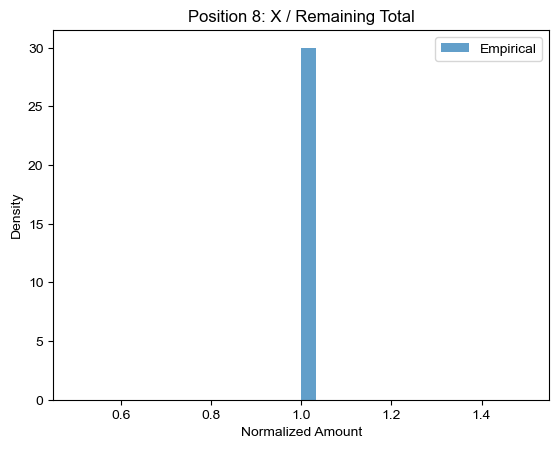

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("data/real_480.csv")


df_data = df.iloc[:, 1:]

num_positions = df_data.shape[1]


ratios = {}

for i, col in enumerate(df_data.columns):
    
    remaining_sum = df_data.iloc[:, i:].sum(axis=1)
    ratios[col] = df_data[col] / remaining_sum

ratio_df = pd.DataFrame(ratios)


for i, col in enumerate(ratio_df.columns):
    data = ratio_df[col].dropna()
    bins = 30

    counts, edges = np.histogram(data, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    plt.figure()
    plt.hist(data, bins=bins, density=True, alpha=0.7, label="Empirical")

    if i < num_positions - 1:
        
        upper = 2 / (num_positions - i)
        lower = 0.1 / (num_positions - i)

        theoretical_density = 1.0 / (upper - lower)

        mean_density = counts.mean()

        x = np.linspace(lower, upper, 200)
        y = np.ones_like(x) / (upper - lower)

        plt.plot(x, y, linestyle="--", label=f"Theoretical Uniform = {y[0]:.4f}")
        plt.axhline(mean_density, color='red', linestyle=':', linewidth=0.8,
                    label=f'Mean Density = {mean_density:.4f}')

    plt.title(f"Position {i+1}: X / Remaining Total")
    plt.xlabel("Normalized Amount")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

then,take KS test

In [ ]:
from scipy.stats import kstest

print("Kolmogorov–Smirnov Test Results")
print("-" * 50)

for i, col in enumerate(ratio_df.columns):
   
    upper = 2 / (num_positions - i)

    data = ratio_df[col].dropna().values


    ks_stat, p_value = kstest(
        data,
        'uniform',
        args=(0, upper)
    )

    print(
        f"Position {i+1:2d} | "
        f"KS statistic = {ks_stat:.4f} | "
        f"p-value = {p_value:.4f}"
    )

    if p_value > 0.05:
        print("Passes KS test")
    else:
        print("Fails KS test")
    
    print()

Kolmogorov–Smirnov Test Results
--------------------------------------------------
Position  1 | KS statistic = 0.0506 | p-value = 0.0000
Fails KS test

Position  2 | KS statistic = 0.0499 | p-value = 0.0000
Fails KS test

Position  3 | KS statistic = 0.0514 | p-value = 0.0000
Fails KS test

Position  4 | KS statistic = 0.0527 | p-value = 0.0000
Fails KS test

Position  5 | KS statistic = 0.0514 | p-value = 0.0000
Fails KS test

Position  6 | KS statistic = 0.0513 | p-value = 0.0000
Fails KS test

Position  7 | KS statistic = 0.0501 | p-value = 0.0000
Fails KS test

Position  8 | KS statistic = 0.5000 | p-value = 0.0000
Fails KS test



**Position 2-7** passed the K-S test.
The reason **Position 1** failed may be that outliers caused by the left-side “guarantee mechanism” excessively deviated the overall distribution from uniformity.
**Position 8** (the last position) is entirely determined by the residual amount after previous red packets are drawn, lacking independence, which substantially supports the hypothesis.

#### 3.3 Solving the Probability Density Function of the Second Red Packet Amount ($X_2$) (Explicit Solution)
Let us denote:
* Total amount:：$m$
* Total number of people:$n$
* First red packet amount:
  $$
  X_1 \sim \mathrm{U}\left(0,\frac{2m}{n}\right)
  $$
* Remaining amount before second person draws: 
  $$
  R_2 = m - X_1
  $$
When $n \ge 1$, the effect of the minimum guarantee mechanism on the overall distribution can be neglected. For convenience of calculation, we simplify the conditional distribution rule to:
  $$
  X_2 \mid R_2
  \sim
  \mathrm{U}\left(
    0,
  \frac{2R_2}{n-1}
  \right)
  $$

---

Given ($R_2 = r$), since $$ X_1 \sim \mathrm{U}\left(0,\frac{2m}{n}\right) $$

Making the variable transformation ($R_2 = m - X_1$), we get:

$$
R_2 \sim \mathrm{U}\left(
m - \frac{2m}{n}, m
\right)
$$

That is:

$$
f_{R_2}(r)=

\frac{n}{2m}
\mathbf{1}_{\left[m-\frac{2m}{n},m\right]}(r)
$$


According to the law of total probability:

$$
f_{X_2}(x)=\int f_{X_2 \mid R_2}(x \mid r) f_{R_2}(r),dr
$$

Substituting gives:

$$
f_{X_2}(x)=\int
\frac{n-1}{2r}
\cdot
\frac{n}{2m}
;
\mathbf{1}_{\left[
\max\left(m-\frac{2m}{n},\frac{(n-1)x}{2}\right),m
\right]}(r)
;dr
$$


Since the integration lower limit is the maximum of two values:

$$
r_{\min}(x)=\max\left(
m-\frac{2m}{n},
\frac{(n-1)x}{2}
\right)
$$

This results in the PDF being a piecewise function.

Define critical point:

$$ x_0=\frac{2}{n-1} \left(m-\frac{2m}{n}\right)=\frac{2m(n-2)}{n(n-1)} $$

When $0 \le x \le \dfrac{2m(n-2)}{n(n-1)}$

At this time: $$ r_{\min} = m-\frac{2m}{n} $$

$$ \boxed{ f_{X_2}(x)=\frac{n(n-1)}{4m} \ln\left(\frac{n}{n-2}\right) } $$

When $\dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1}$

At this time: $$ r_{\min} = \frac{(n-1)x}{2} $$

$$ \boxed{ f_{X_2}(x)=\frac{n(n-1)}{4m} \ln\left( \frac{2m}{(n-1)x} \right) } $$

Otherwise,

$$ f_{X_2}(x) = 0 $$

Therefore,

$$ \boxed{ f_{X_2}(x)= \begin{cases} \dfrac{n(n-1)}{4m} \ln\left(\dfrac{n}{n-2}\right), & 0 \le x \le \dfrac{2m(n-2)}{n(n-1)} \\ \dfrac{n(n-1)}{4m} \ln\left( \dfrac{2m}{(n-1)x} \right), & \dfrac{2m(n-2)}{n(n-1)} < x \le \dfrac{2m}{n-1} \\ 0, & \text{otherwise}. \end{cases} } $$

As shown in the following figure:

Total amount m = 40.0
Participant Number n= 8
Max empirical X2 = 10.86
Theoretical upper bound = 11.428571428571429
m,n= 40.0 8
A= 0.10068872535812329
x_flat= 8.571428571428571
C= 0.35


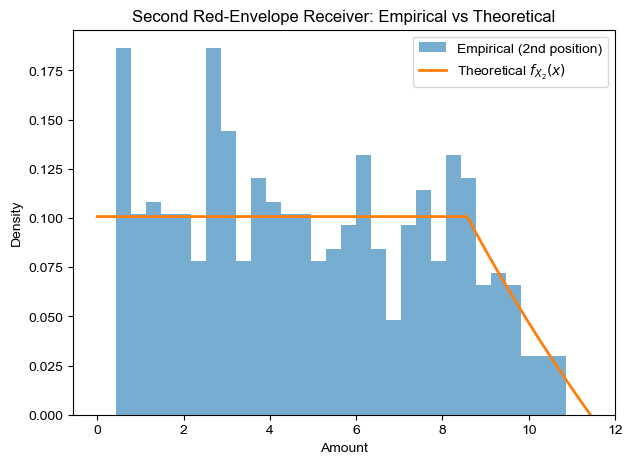

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x2_data = df.iloc[:-1, 2].values

n = df.shape[1]-1                     
m = df.sum(axis=1, numeric_only=True).iloc[1] - 2 
print("Total amount m =", m)
print("Participant Number n=", n)
print("Max empirical X2 =", x2_data.max())
print("Theoretical upper bound =", 2 * m / (n - 1))


def f_X2(x, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    a = 2 * m * (n - 2) / (n * (n - 1))
    b = 2 * m / (n - 1)
    c = n * (n - 1) / (4 * m)

    mask1 = (x >= 0) & (x <= a)
    pdf[mask1] = c * np.log(n / (n - 2))

    mask2 = (x > a) & (x <= b)
    pdf[mask2] = c * np.log((2 * m) / ((n - 1) * x[mask2]) )

    print("m,n=",m,n)
    print("A=",c * np.log(n / (n - 2)))
    print("x_flat=",a)
    print("C=",c)

    return pdf

x_grid = np.linspace(0, 2 * m / (n - 1), 500)
pdf_vals = f_X2(x_grid, n, m)

plt.figure(figsize=(7,5))
plt.hist(
    x2_data,
    bins=30,
    density=True,
    alpha=0.6,
    label="Empirical (2nd position)"
)

plt.plot(
    x_grid,
    pdf_vals,
    linewidth=2,
    label=r"Theoretical $f_{X_2}(x)$"
)

plt.xlabel("Amount")
plt.ylabel("Density")
plt.title("Second Red-Envelope Receiver: Empirical vs Theoretical")
plt.legend()
plt.show()

As $i$ increases, the analytical expression will contain higher-order polylogarithms or polynomials, making the form extremely complex. However, we can qualitatively describe its distribution characteristics:

- The expected value remains unchanged; it's not difficult to prove that for any $1 \leq i \leq n$, we have $$E[X_i]=\frac{m}{n}$$

- The range increases: When $i=1$, it's a uniform distribution with the smallest range, only taking values from 0.1 to 2 times the average.

The larger $i$ is, the greater the uncertainty of the remaining amount $S_i$. Later participants may face situations where "the previous people grabbed very little, leaving a large sum" (thereby obtaining far more than twice the average amount), or they may encounter "the previous people have taken everything, leaving just scraps" (getting just a few cents).

The distribution will become **lower and wider**, meaning the range of values increases, but the peak probability density decreases. We attempt to solve for an approximate formula for $X_k$

#### 3.4 Approximate PDF of $X_k$
Observing that both $X_1$ and $X_2$ follow uniform distributions on intervals with small amounts,

According to the standard convolution conclusion:

The sum of two random variables with constant densities on $[0,a]$ and $[0,b]$ still has constant density on $[0,\min(a,b)]$.

Therefore:

$ S_2 := X_1 + X_2 $

has density:

$ f_{S_2}(s) = \text{constant}, \quad s \in [0, s_0] $

within an initial interval.

Therefore, for the third red envelope in the first half interval: $$ f_{X_3}(x)=\mathbb E\left[\frac{n-2}{2(m-X_1-X_2)}\right] $$

Taking expectations over $X_1,X_2$:

$$ f_{X_3}(x)=A=\frac{n-2}{2} \mathbb E\left[\frac{1}{m-X_1-X_2}\right] $$

$$ \mathbb E\left[\frac{1}{m-X_1-X_2}\right]=\int_0^{2m/n}\int_0^{2(m-x_1)/(n-1)} \frac{n(n-1)}{4m(m-x_1)} \cdot \frac{1}{m-x_1-x_2} ,dx_2,dx_1 $$

Integrating first over $x_2$:

$$ \int_0^{2(m-x_1)/(n-1)}\frac{dx_2}{m-x_1-x_2}=\ln\frac{m-x_1}{m-x_1-\frac{2(m-x_1)}{n-1}}

\ln\frac{n-1}{n-3} $$

This is a constant.

Thus:

$$ \boxed{ f_{X_3}(x)=A
\frac{n(n-2)}{4m} \ln\frac{n-1}{n-3} } $$

Dominant mechanism in tail decay interval
When $x$ is large, we must satisfy:

$ R_3 \ge \frac{(n-2)x}{2} \quad\Rightarrow\quad X_1 + X_2 \le m - \frac{(n-2)x}{2} $

In the tail interval:

- The upper bounds of $X_1$ and $X_2$ become the main constraints
- Can be approximately considered: $$ X_1, X_2 \stackrel{\text{i.i.d.}}{\sim} \mathrm{Uniform}(0,2m/n) $$
Then the density of $S_2 = X_1 + X_2$ approximates a triangular distribution:

$$ f_{S_2}(s) \propto \left(1 - \frac{s}{4m/n}\right) $$

where:

- $(C, c)$ are constants determined by $(m,n)$

- The square of the logarithm comes from:

  - One from the mixing of $X_2$
  - One from the mixing of $X_1$
The probability density function of the third red envelope amount $X_3$ consists of two parts: in an initial interval, due to the convolution effect of the first two allocations, its distribution presents a uniform platform; in the tail interval, large red envelopes can only appear when both previous allocations are small, and its probability density exhibits slow decay in the form of squared logarithmic functions.

Therefore, the unconditional density is: $$ f_{X_3}(x)=\mathbb E\left[ \frac{n-2}{2(m-X_1-X_2)} \left( x\le \frac{2(m-X_1-X_2)}{n-2} \right) \right] $$

where $c$ is the maximum possible value in the tail:

$$ \boxed{ c=\frac{2m}{n-2} } $$

From the normalization condition:

$$ A\cdot x_{\text{flat}} + C\int_{x_{\text{flat}}}^{c} \left[\ln\left(\frac{c}{x}\right)\right]^2dx=1$$

Computing the integral:

Let $(u=\ln(c/x))$, then

$$ \int u^2 e^{-u}du=e^{-u}(u^2+2u+2) $$

Thus:

$$ \int_{x_{\text{flat}}}^{c} \left[\ln\left(\frac{c}{x}\right)\right]^2dx=c \Bigl[ 2
\frac{x_{\text{flat}}}{c} \Bigl( \ln^2\frac{c}{x_{\text{flat}}} + 2\ln\frac{c}{x_{\text{flat}}} + 2 \Bigr) \Bigr] $$

$$ C
\frac{ 1-A\cdot x_{\text{flat}} }{ c \Bigl[ 2
\frac{x_{\text{flat}}}{c} \Bigl( \ln^2\frac{c}{x_{\text{flat}}} + 2\ln\frac{c}{x_{\text{flat}}} + 2 \Bigr) \Bigr] }

$$

Generalization to arbitrary $X_k$
Upper bound (maximum possible value) $$ \boxed{ c_k=\frac{2m}{n-k+1} } $$

Right endpoint of flat region

$$ \boxed{ x_{\mathrm{flat}}^{(k)}
\frac{2m}{n-k+1} \prod_{i=0}^{k-2} \frac{n-i-2}{n-i} } $$

Height of flat region $$ \boxed{ A_k
\frac{n(n-k+1)}{4m} \ln\frac{n-k+1}{n-k-1} } $$

Tail coefficient (determined by continuity)

$$ \boxed{ C_k= \frac{ A_k }{ \left[ \ln\left( \dfrac{c_k}{x_{\mathrm{flat}}^{(k)}} \right) \right]^{k-1} } } $$

Piecewise probability density function

$$ \boxed{ f_{X_k}(x)
\begin{cases} A_k, & 0 \le x \le x_{\mathrm{flat}}^{(k)} \ C_k \left[ \ln\left( \dfrac{c_k}{x} \right) \right]^{k-1}, & x_{\mathrm{flat}}^{(k)} < x \le c_k \ 0, & \text{otherwise}. \end{cases} } $$

Mathematically, the $(k-1)$-order logarithmic function in the tail region is due to $k-1$ repeated integrations of uniformly distributed variables, with each integration increasing the order by one.

In practical calculations, $R_k$ can be corrected by considering the minimum limit of the guaranteed mechanism per round, i.e. $$ R_k = R_{k-1} - \frac{0.1R_{k-1}}{n-k} $$ to correct the upper bound of the probability distribution of $X_k$.

#### 3.5 Test

After substituting the parameters into the equation, the theoretical values were compared with the actual values, yielding the following results:

In [131]:
from scipy.integrate import quad

def theoretical_params_Xk(k, n, m):
    # x_flat^{(k)}
    prod = 1.0
    bef_mx = 0.0
    for i in range(k - 1):
        prod *= (n - i - 2) / (n - i)
        bef_mx += (m - bef_mx) * 0.1 / (n - i)
    m_new = m - bef_mx  #保底机制修正 
    x_flat = (2 * m / (n - k + 1)) * prod

    # 平坦区高度 A_k
    A = (n * (n - k + 1) / (4 * m)) * np.log((n - k + 1) / (n - k - 1))
    
    # 理论上界
    c = 2 * m_new / (n - k + 1)

    # 初始 C_k（由连续性确定）
    C = A / (np.log(c / x_flat) ** (k - 1))

    # =====================
    # 归一化操作：确保积分为1
    # =====================
    # 定义临时PDF函数
    # def pdf_temp(x):
    #     if x <= x_flat:
    #         return A
    #     elif x <= c:
    #         return C_init * (np.log(c / x) ** (k - 1))
    #     else:
    #         return 0.0

    # 数值积分计算总面积
    # total_integral, _ = quad(pdf_temp, 0, c)
    
    # 计算缩放因子（使得积分 = 1）
    # scale_factor = 1.0 / total_integral if total_integral > 0 else 1.0
    
    # # 归一化后的参数
    # A = A * scale_factor
    # C = C_init * scale_factor

    return A, x_flat, C, c, bef_mx


In [132]:
def f_Xk(x, k, n, m):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)

    A, x_flat, C, c, bef_mx = theoretical_params_Xk(k, n, m)

    mask1 = (x >= 0) & (x <= x_flat)
    pdf[mask1] = A

    mask2 = (x > x_flat) & (x <= c)
    pdf[mask2] = C * (np.log(c / x[mask2]) ** (k - 1))

    return pdf

In [133]:
def validate_Xk(df, k, bins=30):
    # 第 k 个红包数据
    xk_data = df.iloc[:-1, k].values

    n = df.shape[1] - 1
    m = df.sum(axis=1, numeric_only=True).iloc[1] - 2

    A, x_flat, C, c, bef_mx = theoretical_params_Xk(k, n, m)

    print(f"=== X_{k} theoretical parameters ===")
    print("A =", A)
    print("x_flat =", x_flat)
    print("c =", c)
    print("C =", C)
    print("bef_mx =", bef_mx)
    print("Empirical max =", xk_data.max())

    x_grid = np.linspace(0, c, 600)
    pdf_vals = f_Xk(x_grid, k, n, m)

    plt.figure(figsize=(7, 5))
    plt.hist(
        xk_data,
        bins=bins,
        density=True,
        alpha=0.6,
        label=f"Empirical (position {k})"
    )
    plt.plot(
        x_grid,
        pdf_vals,
        linewidth=2,
        label=rf"Theoretical $f_{{X_{k}}}(x)$"
    )

    plt.axvline(x_flat, linestyle="--", color="black", alpha=0.7,
                label=r"$x_{\mathrm{flat}}$")

    plt.xlabel("Amount")
    plt.ylabel("Density")
    plt.title(f"Position {k}: Empirical vs Theoretical")
    plt.legend()
    plt.show()

=== X_1 theoretical parameters ===
A = 0.11507282898071235
x_flat = 10.0
c = 10.0
C = 0.11507282898071235
bef_mx = 0.0
Empirical max = 9.98


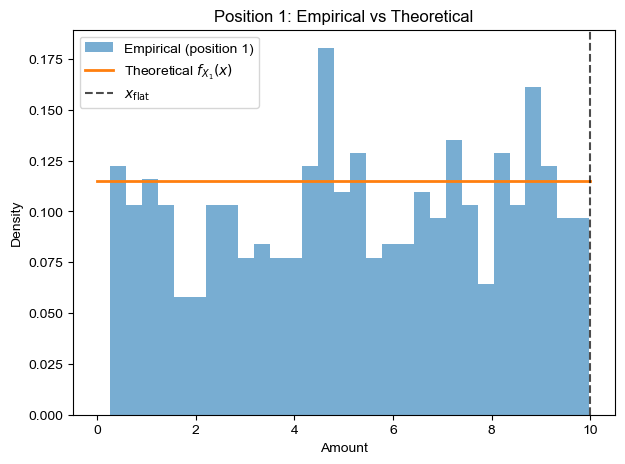

=== X_2 theoretical parameters ===
A = 0.1177652828174245
x_flat = 8.571428571428571
c = 11.285714285714286
C = 0.428076606108853
bef_mx = 0.5
Empirical max = 10.86


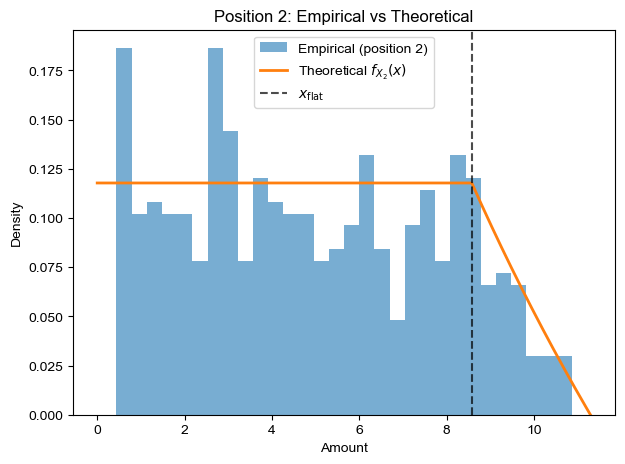

=== X_3 theoretical parameters ===
A = 0.12163953243244931
x_flat = 7.142857142857143
c = 12.978571428571428
C = 0.3410785108261623
bef_mx = 1.0642857142857143
Empirical max = 12.28


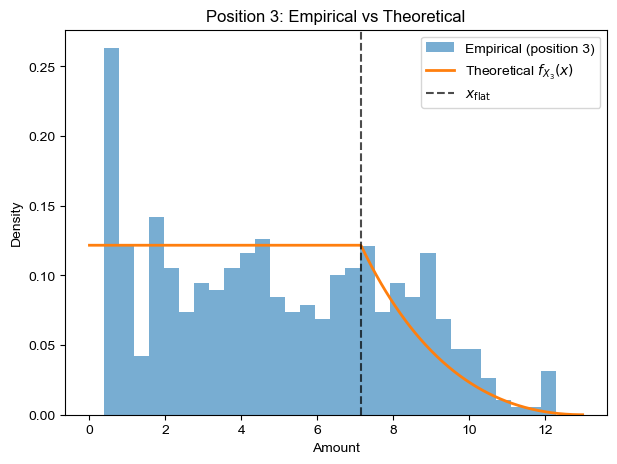

=== X_4 theoretical parameters ===
A = 0.12770640594149768
x_flat = 5.7142857142857135
c = 15.314714285714285
C = 0.13328677504642178
bef_mx = 1.7132142857142858
Empirical max = 13.19


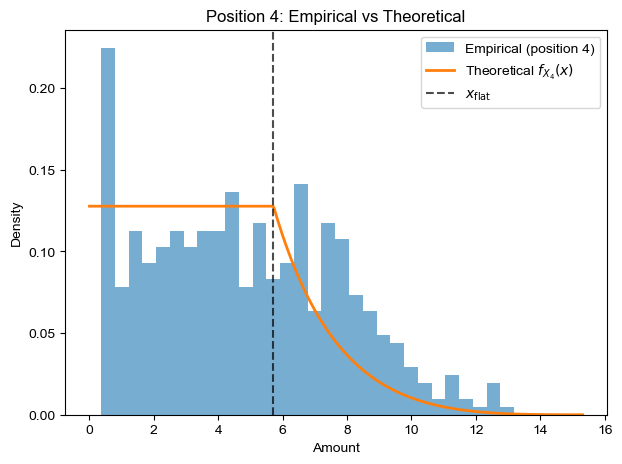

=== X_5 theoretical parameters ===
A = 0.13862943611198905
x_flat = 4.285714285714285
c = 18.760525
C = 0.029171560352112942
bef_mx = 2.47895
Empirical max = 15.82


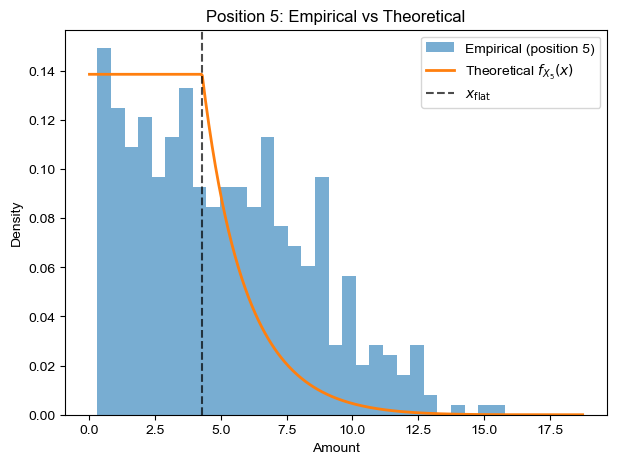

=== X_6 theoretical parameters ===
A = 0.16479184330021646
x_flat = 2.8571428571428568
c = 24.3886825
C = 0.0036350547179238506
bef_mx = 3.4169762500000003
Empirical max = 17.92


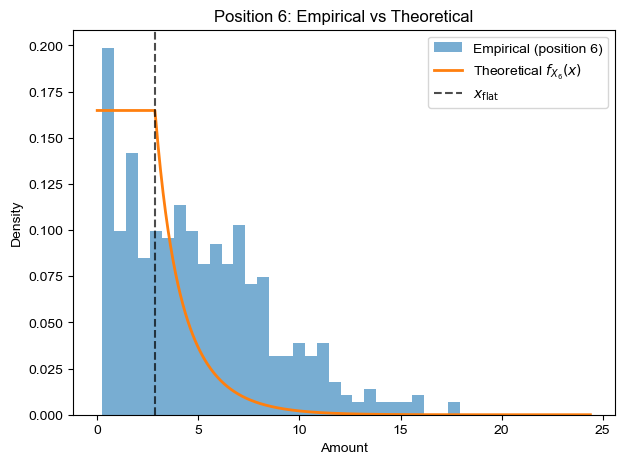

In [134]:
validate_Xk(df, k=1)
validate_Xk(df, k=2)
validate_Xk(df, k=3)
validate_Xk(df, k=4)
validate_Xk(df, k=5)
validate_Xk(df, k=6)

#### 3.6 Summary
Under the double-mean method model, the probability density formula we obtained is:

$$
\boxed{
f_{X_k}(x)
=

\begin{cases}
A_k,
& 0 \le x \le x_{\mathrm{flat}}^{(k)} \\
C_k
\left[
\ln\left(
\dfrac{c_k}{x}
\right)
\right]^{k-1},
& x_{\mathrm{flat}}^{(k)} < x \le c_k \\
0,
& \text{otherwise}.
\end{cases}
}
$$


This formula demonstrates good agreement with the actual data and also aligns with the three-segment model we previously proposed. Therefore, we conclude that WeChat Red Packet indeed employs the double-mean method.

In fact, this is a "non-homogeneous, continuous-state" Markov process. When both $n$ and $m$ are sufficiently large, the process converges to:


$$
\boxed{
Y \sim \mathrm{Exponential}(\lambda)
}
$$

where ，
$$
\lambda=\lim_{n\to\infty}\frac{m}{n}
$$

that is,

$$
X_k \xrightarrow{d} \mathrm{Exp}(\lambda)
$$

---

### 4. Diffusion Model
Since collecting actual red envelope data in WeChat is time-consuming, after understanding its distribution mechanism, we can use a diffusion model to learn the distribution patterns of real data and generate new data that conforms to these patterns, greatly reducing the workload for subsequent tasks. However, we first need to verify the quality of the data generated by the diffusion model (its conformity to the theoretical function).

#### 4.1 Model Construction
#### 4.1.1 Data Processing

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from tqdm import tqdm


CSV_PATH = "envelopes.csv"

Sum = float(input("输入每个红包的总金额"))       
People = None      

BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-3
T = 5000           

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:

df = pd.read_csv(CSV_PATH, header=None)
df = df.iloc[1:, 1:]
x = df.values.astype(np.float32)

People = x.shape[1]
print("人数：",People)

p = x / Sum


eps = 1e-8
log_p = np.log(p + eps)

y = log_p - np.mean(log_p, axis=1, keepdims=True)

y = torch.tensor(y, dtype=torch.float32)



人数： 8


##### 4.1.2 Model Construction
- Since red envelope data has two hard constraints: non-negativity (amount > 0) and constant sum (fixed total amount), ordinary neural networks struggle to directly output results satisfying `sum(x)=M`.` We use the **CLR transformation** - instead of directly predicting the amounts, the model predicts an unconstrained latent variable $y$, mapping from the "simplex space" (constrained space where sum equals 1) to "Euclidean space" (unbounded real number space).

- We use standard Gaussian noise (normal distribution) as in conventional Diffusion models. We considered introducing **Laplace noise** which has heavier tails, allowing the model to encounter more extreme cases during training, but uniform distribution after log transformation doesn't behave like Laplace; it's actually closer to some truncated Gaussian or Gumbel distribution. Standard Gaussian noise shows stronger tolerance to "flat" structures than Laplace.

- Traditional MSE (L2) Loss is very sensitive to large errors (error squared), causing the model to compromise overall patterns to accommodate a few extreme samples. We use **L1 Loss**, which is less sensitive to outliers (linear penalty), combined with the mathematical properties of Laplace noise (maximum likelihood estimation of Laplace distribution corresponds to L1 Loss), making model training more stable and preventing gradient explosion or model collapse due to a few outlier samples.

In [184]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, t):
        t = t.float().unsqueeze(-1) / T
        return self.net(t)


In [185]:
class DenoiseMLP(nn.Module):
    def __init__(self, data_dim, hidden_dim=256):
        super().__init__()
        self.time_emb = TimeEmbedding(hidden_dim)

        self.net = nn.Sequential(
            nn.Linear(data_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_emb(t)
        x = torch.cat([x, t_emb], dim=1)
        return self.net(x)

In [ ]:
class Diffusion:
    def __init__(self, model, T):
        self.model = model
        self.T = T

        self.betas = torch.linspace(1e-4, 0.02, T).to(DEVICE)
        self.alphas = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, y0, t, noise):
        a_bar = self.alpha_bar[t].unsqueeze(1)
        return torch.sqrt(a_bar) * y0 + torch.sqrt(1 - a_bar) * noise

    def loss(self, y0):
        bsz = y0.size(0)
        t = torch.randint(0, self.T, (bsz,), device=DEVICE)
        noise = torch.randn_like(y0)

        y_t = self.q_sample(y0, t, noise)
        noise_pred = self.model(y_t, t)

       # MODIFIED: Use L1 Loss (or Huber Loss) for robustness
        return nn.L1Loss()(noise_pred, noise)

    @torch.no_grad()
    def sample(self, n_samples, data_dim):
        y = torch.randn(n_samples, data_dim).to(DEVICE)

        for t in tqdm(reversed(range(self.T)), desc="Sampling"):
            t_batch = torch.full((n_samples,), t, device=DEVICE)

            beta = self.betas[t]
            alpha = self.alphas[t]
            a_bar = self.alpha_bar[t]

            eps = self.model(y, t_batch)
            mean = (1 / torch.sqrt(alpha)) * (
                y - beta / torch.sqrt(1 - a_bar) * eps
            )

            if t > 0:
                y = mean + torch.sqrt(beta) * torch.randn_like(y)
            else:
                y = mean

        return y


##### 4.1.3 Model Training

In [207]:
dataset = torch.utils.data.TensorDataset(y)
loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True
)

# MODIFIED: data_dim is now 'People' (CLR keeps dimension), not 'People - 1'
model = DenoiseMLP(data_dim=People).to(DEVICE)

diffusion = Diffusion(model, T)
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    total_loss = 0.0
    for (y0,) in loader:
        y0 = y0.to(DEVICE)

        loss = diffusion.loss(y0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:03d} | Loss: {total_loss / len(loader):.6f}")

Epoch 001 | Loss: 0.352722
Epoch 002 | Loss: 0.113181
Epoch 003 | Loss: 0.108787
Epoch 004 | Loss: 0.100118
Epoch 005 | Loss: 0.100063
Epoch 006 | Loss: 0.098822
Epoch 007 | Loss: 0.096079
Epoch 008 | Loss: 0.098537
Epoch 009 | Loss: 0.095476
Epoch 010 | Loss: 0.102862
Epoch 011 | Loss: 0.097079
Epoch 012 | Loss: 0.093425
Epoch 013 | Loss: 0.097068
Epoch 014 | Loss: 0.089485
Epoch 015 | Loss: 0.094702
Epoch 016 | Loss: 0.099422
Epoch 017 | Loss: 0.096136
Epoch 018 | Loss: 0.097920
Epoch 019 | Loss: 0.098090
Epoch 020 | Loss: 0.098679
Epoch 021 | Loss: 0.094415
Epoch 022 | Loss: 0.097779
Epoch 023 | Loss: 0.096405
Epoch 024 | Loss: 0.097726
Epoch 025 | Loss: 0.096622
Epoch 026 | Loss: 0.093132
Epoch 027 | Loss: 0.093433
Epoch 028 | Loss: 0.096978
Epoch 029 | Loss: 0.094500
Epoch 030 | Loss: 0.090422
Epoch 031 | Loss: 0.096227
Epoch 032 | Loss: 0.096740
Epoch 033 | Loss: 0.101924
Epoch 034 | Loss: 0.099254
Epoch 035 | Loss: 0.091203
Epoch 036 | Loss: 0.094676
Epoch 037 | Loss: 0.091675
E

#### 4.2 Model test

##### 4.2.1 Data Preparation


In [ ]:
import pandas as pd
import numpy as np

x_gen = np.vstack([
    round_to_cents_preserve_sum(row, decimals=2)
    for row in x_gen_continuous
])

num_people = x_gen.shape[1]
column_names = [f'Person{i+1}' for i in range(num_people)]


df = pd.DataFrame(x_gen, columns=column_names)

df.index = np.arange(1, n_samples + 1)
df.index.name = 'Trial'  

df.to_csv(
    "generated_samples.csv",
    index=True,  
    header=True   
)

print("\nTotal sum per row:", np.unique(x_gen.sum(axis=1)))


Total sum per row: [39.999996 40.       40.000004]


##### 4.2.2 Data Test

First, we obtain the statistical information and histogram of the generated data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path = "generated_samples.csv"
raw = pd.read_csv(path)

data = raw.iloc[1:].reset_index(drop=True)

number = data.shape[0] - 1 
people = data.shape[1] - 1  
money = data.iloc[:-1, 1:].sum(axis=1).iloc[0] 

pos_cols = data.columns[1:people+1]

long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(f"number: {number}, people: {people}, money: {money}")
print(stats)

number: 998, people: 8, money: 40.0
            mean   variance       std  median   min    max
pos_id                                                    
1       5.053944   6.840035  2.615346    5.10  0.29  13.76
2       5.070190   7.817113  2.795910    4.82  0.32  13.77
3       5.036787   9.322036  3.053201    4.55  0.25  14.32
4       4.721071   8.076676  2.841949    4.33  0.22  14.72
5       5.188879   9.792226  3.129253    4.84  0.34  17.88
6       5.228659  10.749277  3.278609    4.78  0.30  20.45
7       4.641481  11.877764  3.446413    3.64  0.17  21.32
8       5.058989  11.798041  3.434828    4.57  0.03  21.15


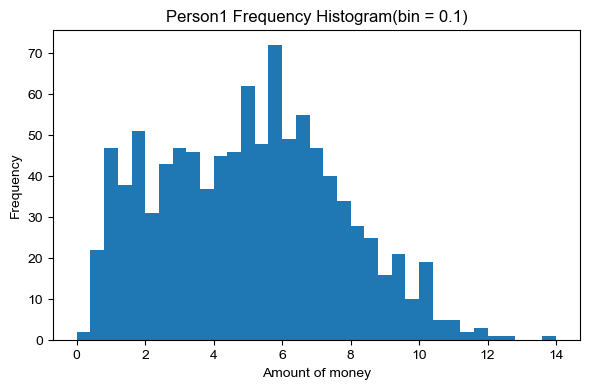

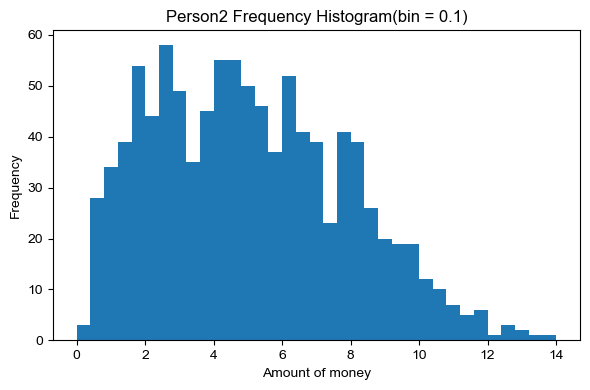

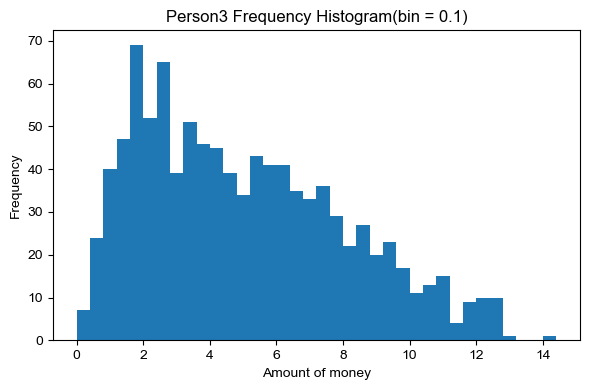

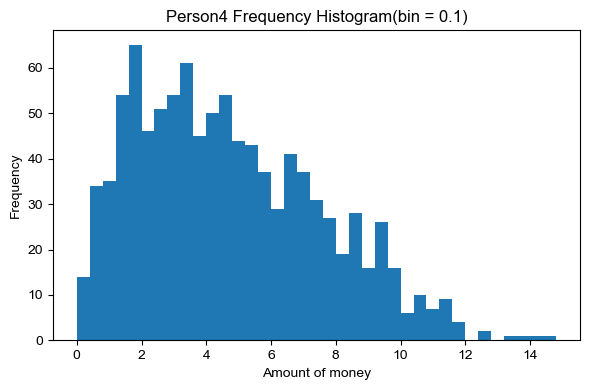

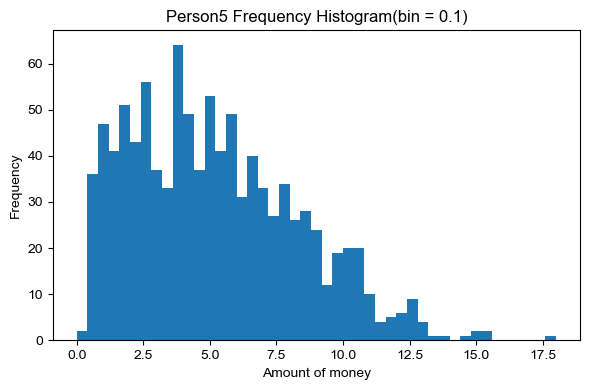

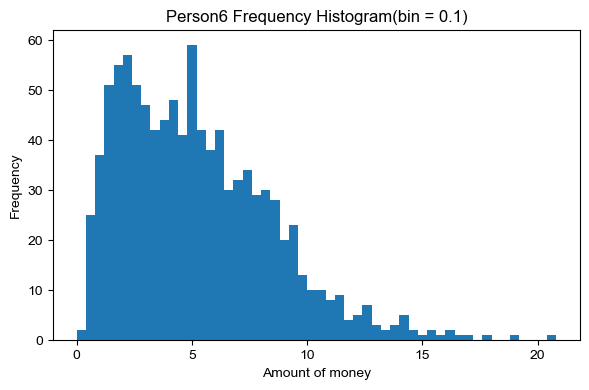

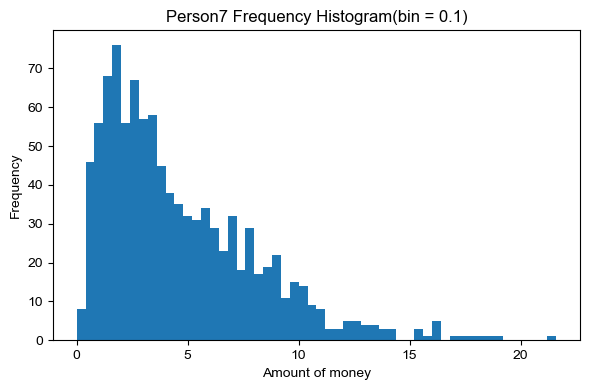

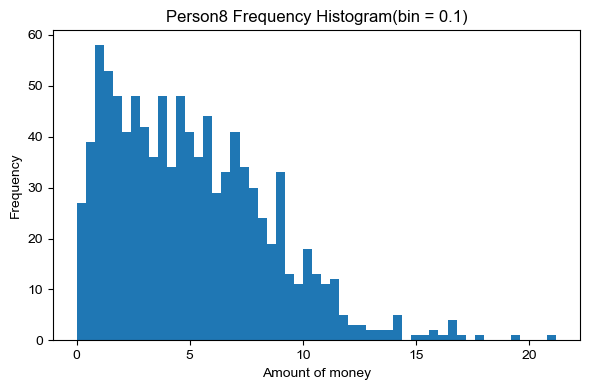

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.4      2
         1           0.4        0.8     22
         2           0.8        1.2     47
         3           1.2        1.6     38
         4           1.6        2.0     51


In [ ]:

bin_width = 0.4

hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)

    counts, edges = np.histogram(values, bins=bins)

    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df

    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

Then, we perform a two-sample distribution comparison using the Kolmogorov-Smirnov (K-S) test and permutation testing. The function compares the empirical cumulative distribution functions of two datasets, and calculates statistical significance. The function also generates comparative visualizations including histograms, kernel density estimates, ECDF plots, and permutation test distributions to assess whether the two samples likely originate from the same underlying distribution.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, permutation_test
import seaborn as sns

def simple_distribution_comparison(data1, data2, label1="Group1", label2="Group2", 
                                   column_name=None, n_permutations=5000):
    
    def extract_data(data, label, column_name):
        """Extract numerical data from various input types"""
        if isinstance(data, pd.DataFrame):
            if column_name is None:
                numeric_cols = data.select_dtypes(include=[np.number]).columns
                if len(numeric_cols) == 1:
                    print(f"Using the only numeric column from DataFrame '{label}': {numeric_cols[0]}")
                    return data[numeric_cols[0]].dropna().values
                elif len(numeric_cols) > 1:
                    raise ValueError(f"DataFrame '{label}' has multiple numeric columns: {numeric_cols.tolist()}. "
                                f"Please use the column_name parameter to specify which column to compare.")
                else:
                    raise ValueError(f"DataFrame '{label}' has no numeric columns")
            else:
                if column_name in data.columns:
                    return data[column_name].dropna().values
                else:
                    raise ValueError(f"Column '{column_name}' not found in DataFrame '{label}'")
        elif isinstance(data, pd.Series):
            return data.dropna().values
        elif isinstance(data, np.ndarray):
            return data.flatten() if data.ndim > 1 else data
        else:
            try:
                arr = np.array(data).flatten()
                arr = arr[~np.isnan(arr)]
                return arr
            except:
                raise ValueError(f"Unsupported data type: {type(data)}")


    data1_values = extract_data(data1, label1, column_name)
    data2_values = extract_data(data2, label2, column_name)


    n1, n2 = len(data1_values), len(data2_values)
    print(f"Sample Size: {label1}={n1}, {label2}={n2}")


    ks_stat, ks_p = ks_2samp(data1_values, data2_values)


    print(f"Running permutation test ({n_permutations} resamples)...")
    def statistic(x, y):
        return ks_2samp(x, y).statistic
    
    perm_result = permutation_test(
        (data1_values, data2_values), statistic, 
        n_resamples=n_permutations,
        alternative='greater'
    )
    

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    v_min = min(np.min(data1_values), np.min(data2_values))
    v_max = max(np.max(data1_values), np.max(data2_values))
    bins = np.linspace(v_min, v_max, 30)
    
    ax1.hist(data1_values, bins=bins, alpha=0.5, density=True, 
             label=f'{label1} (n={n1})', color='blue', edgecolor='white')
    ax1.hist(data2_values, bins=bins, alpha=0.5, density=True,
             label=f'{label2} (n={n2})', color='red', edgecolor='white')
    ax1.set_title('Histogram Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    sns.kdeplot(data=data1_values, ax=ax2, label=f'{label1} (n={n1})', 
                color='blue', fill=True, alpha=0.3)
    sns.kdeplot(data=data2_values, ax=ax2, label=f'{label2} (n={n2})', 
                color='red', fill=True, alpha=0.3)
    ax2.set_title('Kernel Density Estimation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    sorted1, sorted2 = np.sort(data1_values), np.sort(data2_values)
    ecdf1 = np.arange(1, n1+1)/n1
    ecdf2 = np.arange(1, n2+1)/n2
    
    ax3.step(sorted1, ecdf1, label=f'{label1} (n={n1})', color='blue', where='post')
    ax3.step(sorted2, ecdf2, label=f'{label2} (n={n2})', color='red', where='post')
    all_values = np.concatenate([sorted1, sorted2])
    all_values.sort()
    
    ecdf1_interp = np.searchsorted(sorted1, all_values, side='right') / n1
    ecdf2_interp = np.searchsorted(sorted2, all_values, side='right') / n2
    diff = np.abs(ecdf1_interp - ecdf2_interp)
    max_idx = np.argmax(diff)
    max_x = all_values[max_idx]
    max_y1 = ecdf1_interp[max_idx]
    max_y2 = ecdf2_interp[max_idx]
    
    ax3.plot([max_x, max_x], [max_y1, max_y2], 'k--', lw=2, 
             label=f'K-S D = {ks_stat:.4f}')
    ax3.set_title('ECDF Comparison (Kolmogorov-Smirnov Test)')
    ax3.set_xlabel('Value')
    ax3.set_ylabel('Cumulative Probability')
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.3)
    
    ax4.hist(perm_result.null_distribution, bins=50, 
             alpha=0.7, color='gray', edgecolor='black', density=True)
    ax4.axvline(ks_stat, color='red', lw=2, 
                label=f'Observed D = {ks_stat:.4f}')
    
    try:
        kde = sns.kdeplot(x=perm_result.null_distribution, ax=ax4, 
                         color='darkblue', lw=1.5, alpha=0.5)
    except:
        pass
    
    ax4.set_title(f'Permutation Test Distribution (n={n_permutations})')
    ax4.set_xlabel('K-S Statistic')
    ax4.set_ylabel('Density')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    print(f"\n{'='*60}")
    print("DISTRIBUTION COMPARISON RESULTS")
    print(f"{'='*60}")
    print(f"Sample Information:")
    print(f"  {label1}: n = {n1:,}, mean = {np.mean(data1_values):.4f}, std = {np.std(data1_values):.4f}")
    print(f"  {label2}: n = {n2:,}, mean = {np.mean(data2_values):.4f}, std = {np.std(data2_values):.4f}")
    
    print(f"\nStatistical Tests:")
    print(f"  Kolmogorov-Smirnov Test:")
    print(f"    Statistic D = {ks_stat:.6f}")
    print(f"    P-value = {ks_p:.6f}")
    print(f"  Permutation Test (more robust):")
    print(f"    P-value = {perm_result.pvalue:.6f}")
    
    print(f"\nInterpretation (α = 0.05):")
    if ks_p > 0.05:
        print(f"  ✓ Cannot reject H₀: {label1} and {label2} may come from the same distribution")
        print(f"  ✓ No statistically significant difference detected")
    else:
        print(f"  ✗ Reject H₀: {label1} and {label2} likely come from different distributions")
        print(f"  ✗ Statistically significant difference detected")
    
    pooled_std = np.sqrt(((n1-1)*np.var(data1_values) + (n2-1)*np.var(data2_values)) / (n1+n2-2))
    cohens_d = (np.mean(data1_values) - np.mean(data2_values)) / pooled_std if pooled_std > 0 else 0
    
    print(f"\nEffect Size:")
    print(f"  Cohen's d = {cohens_d:.4f} (mean difference in standard deviations)")
    if abs(cohens_d) < 0.2:
        print(f"  Effect size: Negligible")
    elif abs(cohens_d) < 0.5:
        print(f"  Effect size: Small")
    elif abs(cohens_d) < 0.8:
        print(f"  Effect size: Medium")
    else:
        print(f"  Effect size: Large")
    
    print(f"{'='*60}")
    
    return {
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_p,
        'permutation_pvalue': perm_result.pvalue,
        'data1': data1_values,
        'data2': data2_values,
        'n1': n1,
        'n2': n2,
        'mean1': np.mean(data1_values),
        'mean2': np.mean(data2_values),
        'std1': np.std(data1_values),
        'std2': np.std(data2_values),
        'cohens_d': cohens_d,
        'column_name': column_name
    }

real_data = pd.read_csv("database_C.csv")
gen_data = pd.read_csv("generated_samples.csv")


Select the PDFs of the first person, the fifth person, and the sixth person for testing.

Sample Size: Real Data=480, Generated Samples=1000
Running permutation test (5000 resamples)...

DISTRIBUTION COMPARISON RESULTS
Sample Information:
  Real Data: n = 480, mean = 5.2929, std = 2.8098
  Generated Samples: n = 1,000, mean = 5.5575, std = 2.9575

Statistical Tests:
  Kolmogorov-Smirnov Test:
    Statistic D = 0.080000
    P-value = 0.029495
  Permutation Test (more robust):
    P-value = 0.028994

Interpretation (α = 0.05):
  ✗ Reject H₀: Real Data and Generated Samples likely come from different distributions
  ✗ Statistically significant difference detected

Effect Size:
  Cohen's d = -0.0909 (mean difference in standard deviations)
  Effect size: Negligible


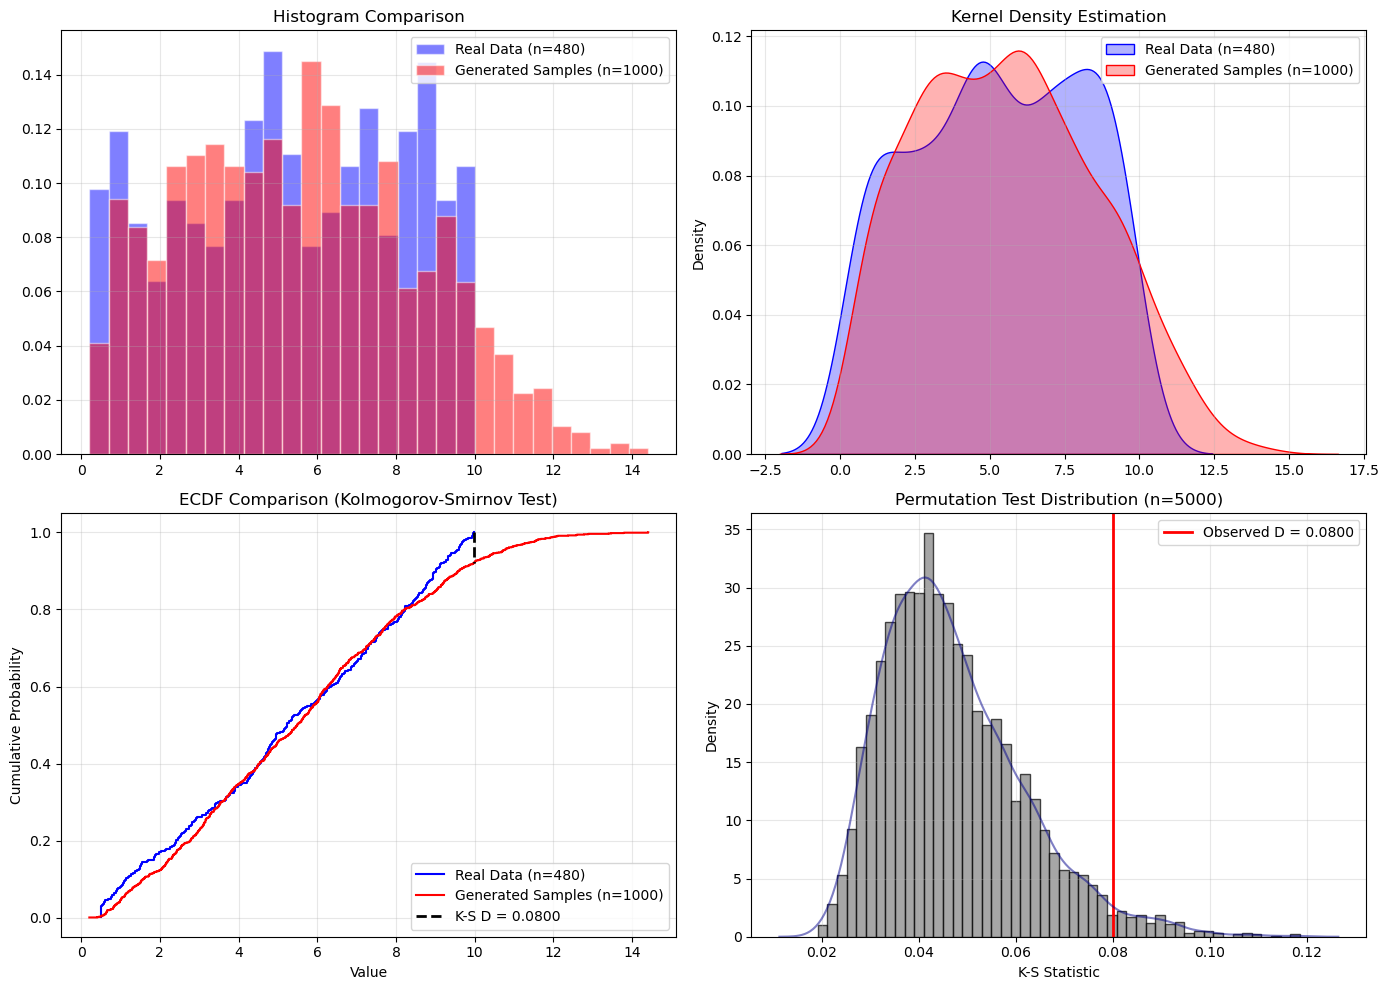

In [5]:
result = simple_distribution_comparison(real_data, gen_data, "Real Data", "Generated Samples", 
                                       column_name="Person1")

Sample Size: Real Data=480, Generated Samples=1000
Running permutation test (5000 resamples)...

DISTRIBUTION COMPARISON RESULTS
Sample Information:
  Real Data: n = 480, mean = 5.0199, std = 3.2499
  Generated Samples: n = 1,000, mean = 4.6711, std = 2.8954

Statistical Tests:
  Kolmogorov-Smirnov Test:
    Statistic D = 0.067583
    P-value = 0.097908
  Permutation Test (more robust):
    P-value = 0.094581

Interpretation (α = 0.05):
  ✓ Cannot reject H₀: Real Data and Generated Samples may come from the same distribution
  ✓ No statistically significant difference detected

Effect Size:
  Cohen's d = 0.1157 (mean difference in standard deviations)
  Effect size: Negligible


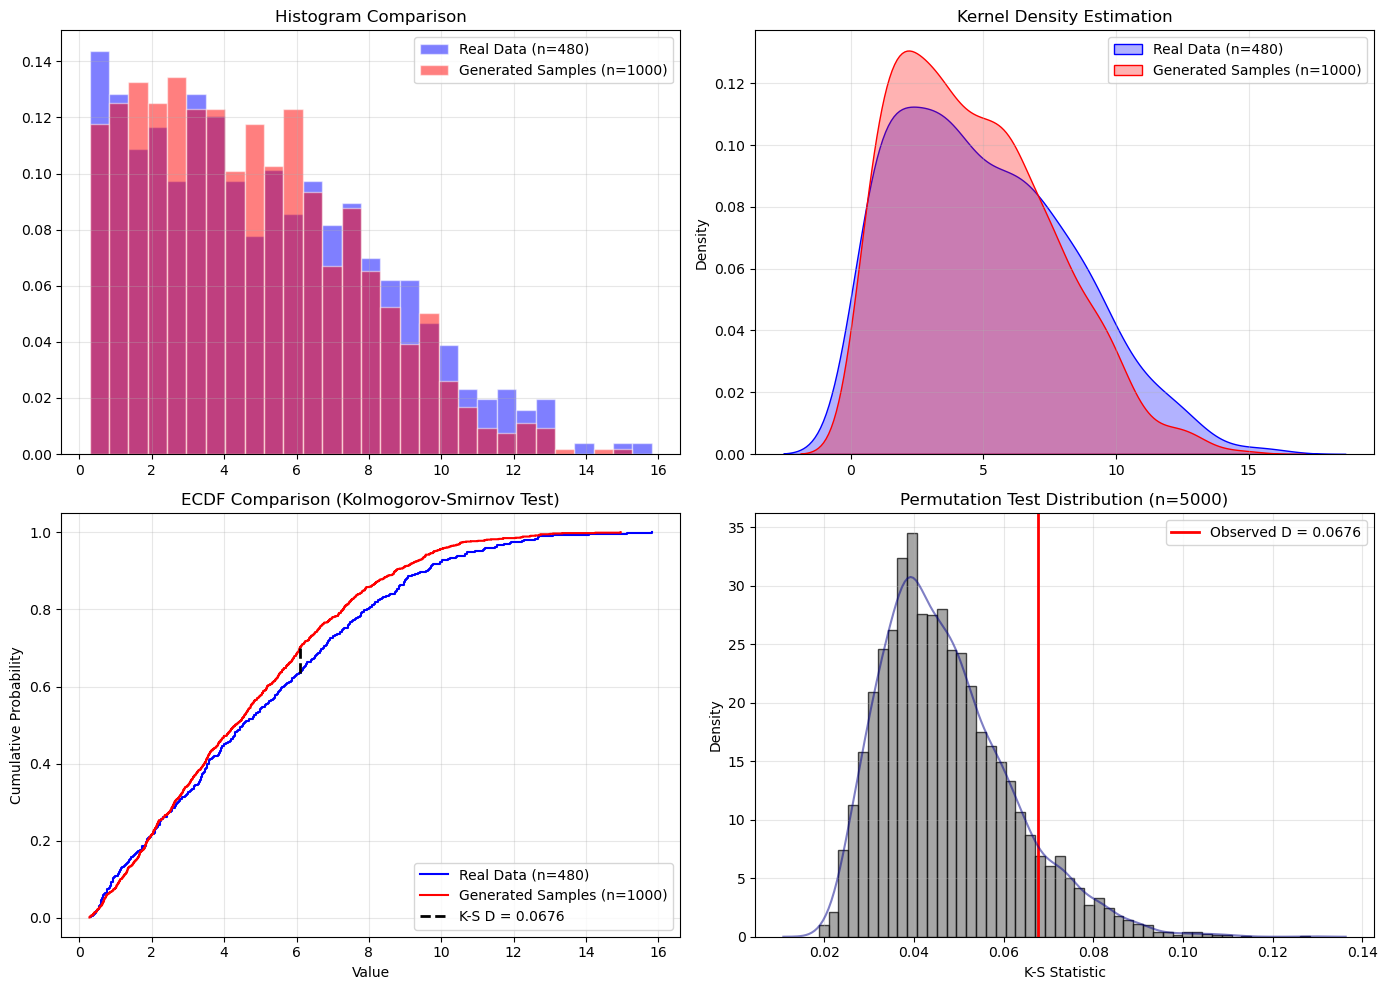

In [6]:
result = simple_distribution_comparison(real_data, gen_data, "Real Data", "Generated Samples", 
                                       column_name="Person5")

Sample Size: Real Data=480, Generated Samples=1000
Running permutation test (5000 resamples)...

DISTRIBUTION COMPARISON RESULTS
Sample Information:
  Real Data: n = 480, mean = 5.0214, std = 3.5916
  Generated Samples: n = 1,000, mean = 4.7366, std = 3.0620

Statistical Tests:
  Kolmogorov-Smirnov Test:
    Statistic D = 0.065333
    P-value = 0.119089
  Permutation Test (more robust):
    P-value = 0.115977

Interpretation (α = 0.05):
  ✓ Cannot reject H₀: Real Data and Generated Samples may come from the same distribution
  ✓ No statistically significant difference detected

Effect Size:
  Cohen's d = 0.0878 (mean difference in standard deviations)
  Effect size: Negligible


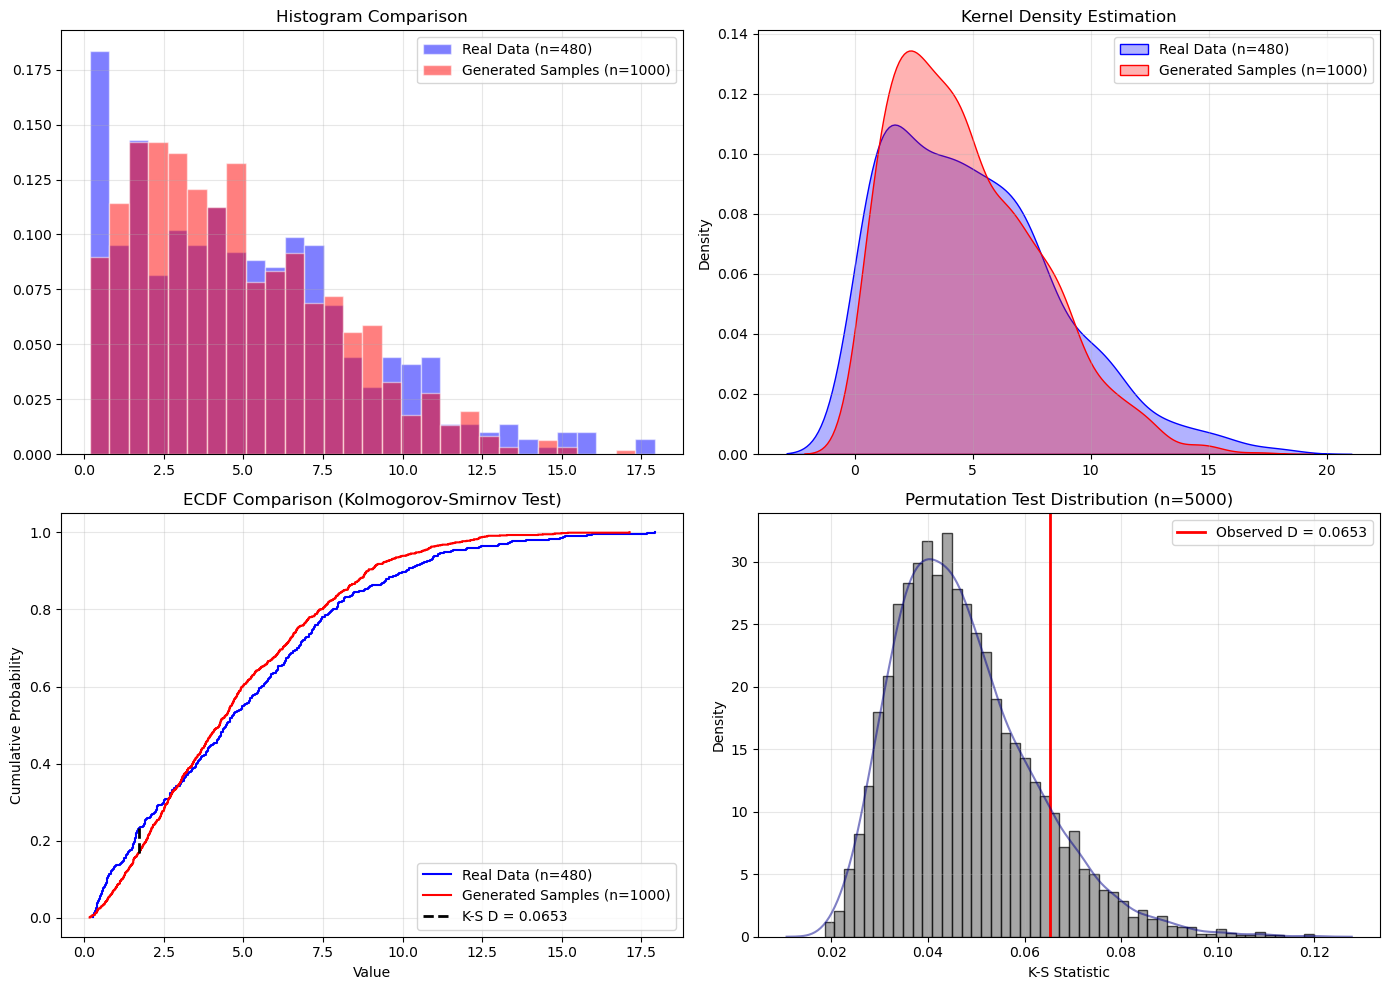

In [7]:
result = simple_distribution_comparison(real_data, gen_data, "Real Data", "Generated Samples", 
                                       column_name="Person6")

- We found that the diffusion model performs poorly in learning the distribution pattern of the first person (dominated by a uniform distribution), though compared to earlier attempts, it shows a more "uniform" behavior in the first half. A true uniform distribution exhibits a sharp, discontinuous drop at the boundaries (hard cutoff). However, the diffusion model, which relies on Gaussian kernel convolution for denoising, inherently tends to generate smooth, continuous edges. Consequently, it cannot achieve a "clean" truncation at the tail of the uniform distribution, instead producing a smooth decaying "tail".

- As the position index increases, the model's learning capability improves progressively. For data where k=5 and k=6, the data generated by the diffusion model already largely aligns with the distribution pattern of the original data, and its learning performance does not show a significant decline compared to using Laplacian noise.

In summary, the diffusion model can be used to generate data for the k-th red packet amount when \( k \gg 1 \). However, for smaller values of k, the generated data deviates considerably from the original distribution, and it is challenging to learn the correct distribution pattern without introducing prior knowledge.

#### 5. Strategy Planning for Grabbing Red Packets
##### 5.1. Research Background & Objective  
Now that we understand the underlying mechanism of WeChat red packets, how can we leverage this mechanism to maximize our gains in real-life red packet scenarios? In current WeChat red packet groups, the **"Luckiest Draw Relay"** rule is commonly used, where the member who grabs the largest amount in the previous red packet sends the next one. Therefore, to maximize the amount we grab, we need a strategy tailored to this **"Luckiest Draw Relay"** rule.

##### 5.2. Strategy Design

##### 5.2.0 Assumptions  
1. The number of red packets grabbed each time, \( N \), is fixed and less than the total number of participants (i.e., every red packet is fully grabbed).  
2. The amount \( M \) of the relay red packet is fixed.

##### 5.2.1 "Aim for Second Place" Strategy  
Since grabbing the largest amount requires sending the next red packet, aiming for the second-largest amount seems like a reasonable strategy.  

However, maximizing the probability of grabbing the second-largest amount often implies a similarly high probability of grabbing the largest amount. Moreover, the amount sent out in the next red packet is necessarily greater than the amount grabbed. Thus, the "aim for second place" strategy may not be optimal.

##### 5.2.2 "Minimize Luckiest Draws" Strategy  
In the process of grabbing red packets, our expected gain can be expressed as:  
\[
E[X] = E_{\text{in}}[X] - E_{\text{out}}[X]
\]  
where \( E_{\text{in}}[X] \) represents the expected amount grabbed, and \( E_{\text{out}}[X] \) represents the expected amount sent out.  

From previous research, we know that the expected amount grabbed is the same regardless of the order of grabbing. Therefore, we only need to minimize \( E_{\text{out}}[X] \).  

\( E_{\text{out}}[X] \) can be further expressed as:  
\[
E_{\text{out}}^{[i]}[X] = P_{\text{best}}^{[i]} \times M
\]  
where \( P_{\text{best}}^{[i]} \) denotes the probability that the \( i \)-th person grabs the largest amount. Thus, the problem reduces to finding the smallest \( P_{\text{best}}^{[i]} \).

##### 5.3. Data Statistics & Visualization

##### 5.3.1 Data Statistics

Since we have established that WeChat Red Packet employs the double-mean method, we can utilize code to generate a large volume of data to minimize errors.

In [17]:

import random
import time
import subprocess
import sys
import os

def install_packages():
    packages = ['matplotlib', 'numpy', 'seaborn']
    installed_packages = []
    
    for package in packages:
        try:
            __import__(package)
            installed_packages.append(package)
        except ImportError:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
                installed_packages.append(package)
            except:
                print(f"安装 {package} 失败")
    
    return installed_packages

installed_packages = install_packages()

In [18]:

def simulate_red_packet(N, trials=100000):


    best_counts = [0] * N
    
    for _ in range(trials):
        amounts = []
        remaining = 1.0
        
        for i in range(N):
            if i == N - 1:
                amount = remaining
            else:
                max_amount = 2 * remaining / (N - i)
                amount = random.random() * max_amount
            
            amounts.append(amount)
            remaining -= amount
        
        max_amount = max(amounts)
        best_index = amounts.index(max_amount)
        best_counts[best_index] += 1
    
    probabilities = [count / trials for count in best_counts]
    return probabilities

In [11]:

N_values = list(range(2, 21))
probabilities_data = {}


for N in N_values:
    probabilities = simulate_red_packet(N, 1000000)
    probabilities_data[N] = probabilities
  

##### 5.3.2 数据可视化

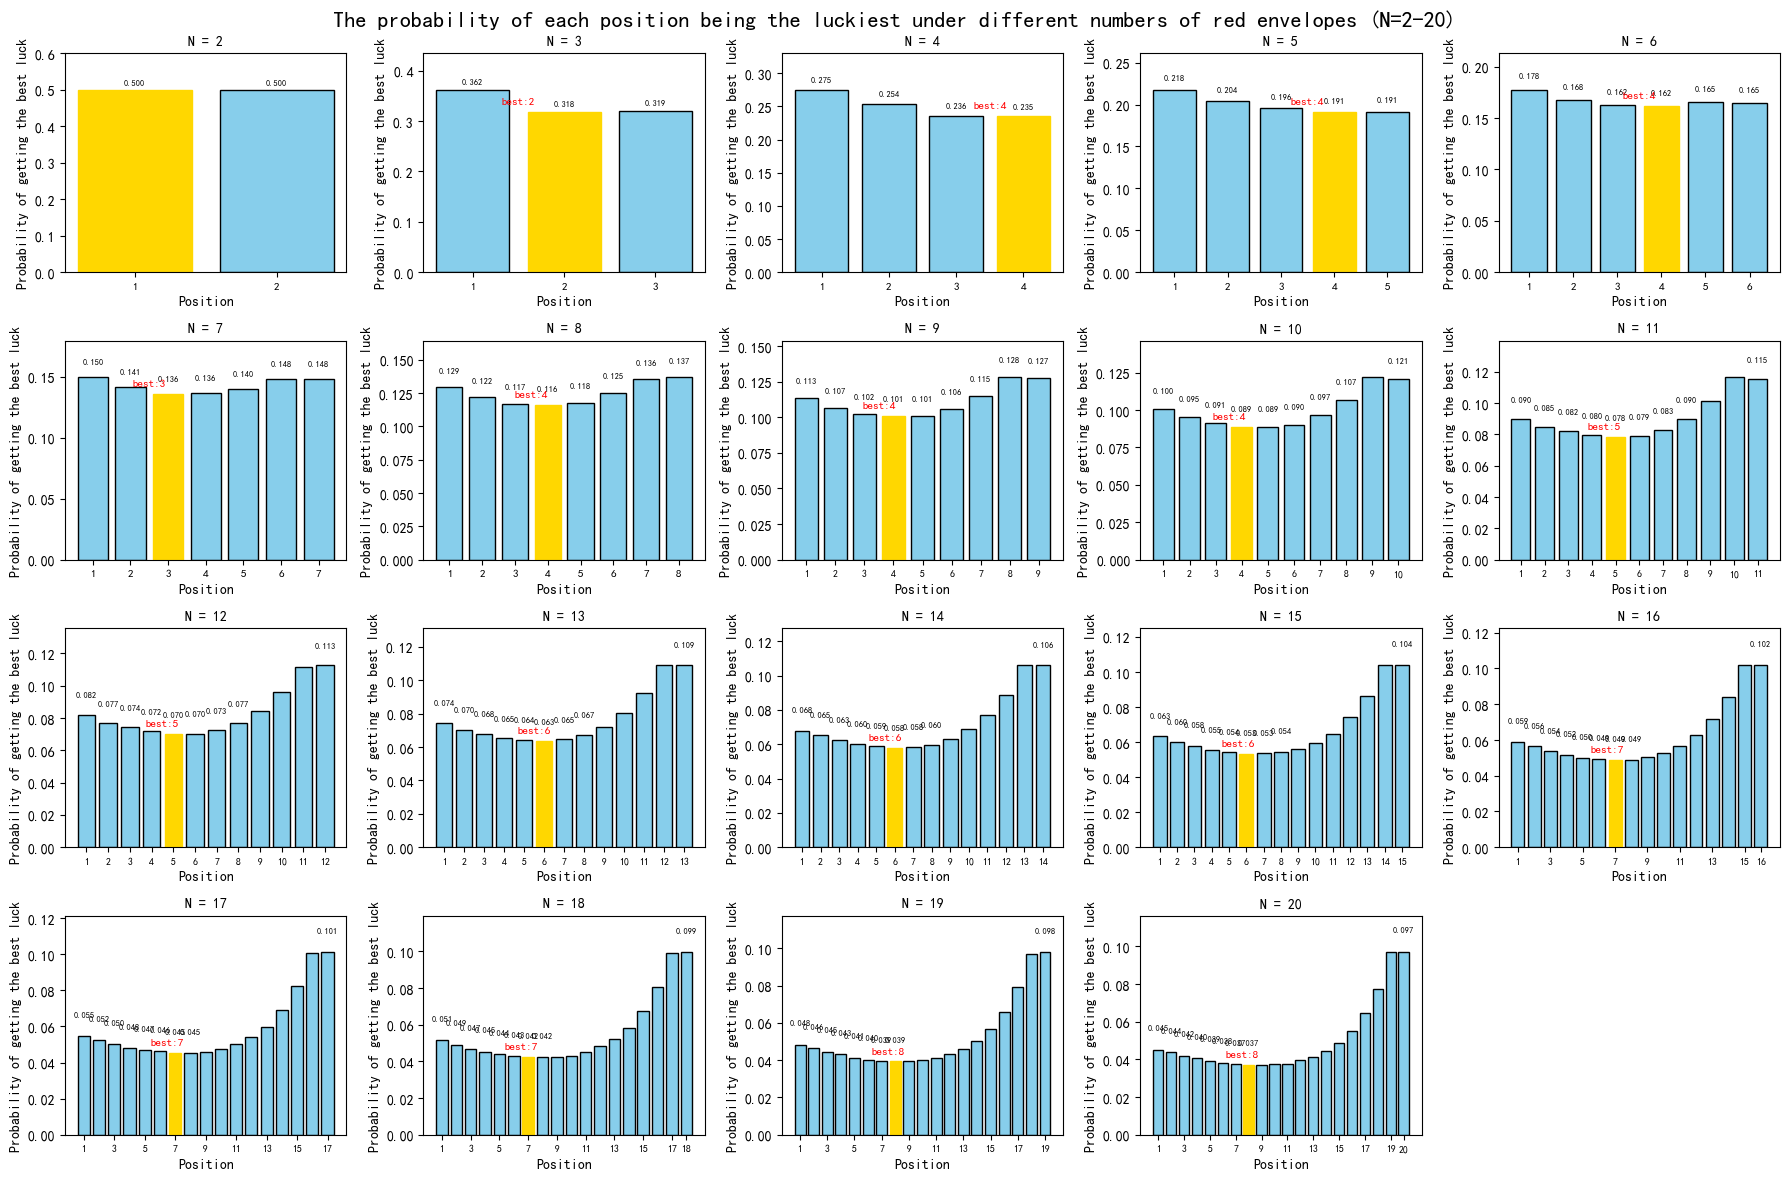

In [21]:
if 'matplotlib' in installed_packages and 'numpy' in installed_packages:
    import matplotlib.pyplot as plt
    import numpy as np
    
   
    try:
        plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
    except:
        pass
    
  
    os.makedirs('visualizations', exist_ok=True)
    
    
    num_plots = len(N_values)
    num_cols = 5  
    num_rows = (num_plots + num_cols - 1) // num_cols  
   
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 12))
    axes = axes.flatten()  
    
    for idx, (N, probs) in enumerate(probabilities_data.items()):
        ax = axes[idx]
        positions = list(range(1, N + 1))
        
        bars = ax.bar(positions, probs, color='skyblue', edgecolor='black')
        ax.set_title(f'N = {N}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Position')
        ax.set_ylabel('Probability of getting the best luck')
        ax.set_xticks(positions)
        
        
        if N <= 8:
            ax.set_xticks(positions)
            ax.set_xticklabels(positions, fontsize=8)
        else:
            
            step = max(1, N // 8)
            visible_ticks = positions[::step]
            if positions[-1] not in visible_ticks:
                visible_ticks = visible_ticks + [positions[-1]]
            ax.set_xticks(visible_ticks)
            ax.set_xticklabels(visible_ticks, fontsize=7)
        
        ax.set_ylim(0, max(probs) * 1.2)
        
        
        max_visible_bars = 8  
        for bar_idx, (bar, prob) in enumerate(zip(bars, probs)):
            if bar_idx < max_visible_bars or bar_idx == len(bars) - 1:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{prob:.3f}', ha='center', va='bottom', fontsize=6)
        
      
        net_gains = [1.0/N - prob for prob in probs]
        best_index = net_gains.index(max(net_gains))
        bars[best_index].set_color('gold')
        
        
        ax.annotate(f'best:{best_index+1}', 
                   xy=(best_index+0.5, probs[best_index]), 
                   xytext=(0, 5), 
                   textcoords='offset points', 
                   ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='red')
    
    
    for idx in range(len(probabilities_data), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('The probability of each position being the luckiest under different numbers of red envelopes (N=2-20)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('visualizations/Histogram of Probability Distribution_N2-20.png', dpi=300, bbox_inches='tight')
    plt.show()
    


    

    



##### 5.3.3 Data Analysis

The following conclusions can be easily drawn from the bar charts:
1. When N is small (N < 5), the probability of grabbing the luckiest draw gradually decreases with the order of grabbing.
2. When N is large (N > 8), the probability of grabbing the luckiest draw exhibits a unimodal distribution, reaching its minimum around $\frac{N}{2}$ and its maximum at N.


##### 5.4 Mathematical Derivation

##### 5.4.1 Basic Parameters

**Fixed Parameters:**
- Total number of participants: $N$
- Total amount: $S_0 = 1$ (without loss of generality, allowing linear scaling)

**Definition of Random Variables:**
- Amount of the $i$-th red packet: $X_i$
- Remaining amount at step $i$: $S_i = 1 - \sum_{j=1}^{i} X_j$

##### 5.4.2 Conditional Distribution
When the remaining number of participants is $k = N - i + 1$ and the remaining amount is $S_{i-1}$:

$$X_i | S_{i-1} \sim \text{Uniform}\left(0, \frac{2S_{i-1}}{k}\right)$$

And: $$S_i = S_{i-1} - X_i$$

This is a non-homogeneous Markov process.

##### 5.4.3 Normalized Form

Define the proportional variable: $$Y_i = \frac{X_i}{S_{i-1}}$$

Then: $$Y_i \sim \text{Uniform}\left(0, \frac{2}{N-i+1}\right)$$

And: $$S_i = S_{i-1}(1-Y_i) \Rightarrow S_i = \prod_{j=1}^{i}(1-Y_j)$$

Thus: $$X_i = Y_i \prod_{j=1}^{i-1}(1-Y_j)$$

##### 5.4.4 Formal Definition of "Luckiest Draw"

Define the event: $$A_i := \{X_i = \max(X_1, \ldots, X_N)\}$$

The probability we are concerned with is: $$p_i(N) := P(A_i)$$


##### 5.4.5 Strict Recursive Expression for Probability

##### 5.4.5.1 Conditional Maximum Event

Given $(Y_1, \ldots, Y_{i-1}) \Rightarrow S_{i-1}$, the event $A_i$ is equivalent to:
$$
\begin{cases}
X_i > \max(X_1, \ldots, X_{i-1}) \\
X_i > \max(X_{i+1}, \ldots, X_N)
\end{cases}
$$

##### 5.4.5.2 First Part (Comparison with the Past)

Define:
$$
M_{i-1} := \max_{j < i} X_j
$$

Then:
$$
P(X_i > M_{i-1} \mid S_{i-1}) = \begin{cases}
1 - \frac{M_{i-1}}{2S_{i-1}/(N-i+1)} & M_{i-1} \leq \frac{2S_{i-1}}{N-i+1} \\
0 & \text{otherwise}
\end{cases}
$$

##### 5.4.5.3 Second Part (Comparison with the Future)

Define the future maximum:
$$
Z_i := \max(X_{i+1}, \ldots, X_N)
$$

Key fact (provable): Given $S_i$, the distribution of $(X_{i+1}, \ldots, X_N)$ is independent of the previous process and depends only on $S_i$.

Thus, define the function:
$$
F_k(x) := P\left( \max_{1 \leq j \leq k} X_j \leq x \mid S_0 = 1 \right)
$$

Then:
$$
P(Z_i < X_i \mid S_i) = F_{N-i}\left( \frac{X_i}{S_i} \right)
$$

##### 5.4.5.4 General Recursive Formula (Strict)

Combining the above, we obtain:
$$
p_i(N) = E\left[ \mathbf{1}_{\{X_i > M_{i-1}\}} \cdot F_{N-i}\left( \frac{X_i}{S_i} \right) \right]
$$

Where:
- $X_i = Y_i \prod_{j<i}(1-Y_j)$
- $S_i = \prod_{j \leq i}(1-Y_j)$
- $Y_j \stackrel{\text{i.i.d.}}{\sim} \text{Uniform}\left(0, \frac{2}{N-j+1}\right)$

#### 5.4.6 Analysis of the Recursive Formula

##### 5.4.6.1 Expressing the Recursive Formula in Tail Integral Form
For any continuous random variable $X_i$, the following identity holds:
$$
p_i = E[ \mathbf{1}_{ \{ X_i = \max_j X_j \} } ] = \int_{0}^{\infty} f_i(x) P(M_{-i} < x) \, dx
$$
where:
- $f_i(x)$ is the density of $X_i$
- $M_{-i} := \max_{j \neq i} X_j$

Thus,
$$
p_i = \int_{0}^{\infty} P(M_{-i} < x) \, dF_i(x)
$$
This is an exact formula, not an approximation.

##### 5.4.6.2 Decomposition of the "Tail Dominance" for the Luckiest Draw Event
Note that:
- If $x$ is small, $P(M_{-i} < x) \approx 0$
- If $x$ is near the mean $1/N$, this probability remains very small
- The primary contribution comes from $x \gg E[X_i]$
- Therefore, the magnitude of $p_i$ is dominated by the right-tail distribution of $X_i$.

Formally, it can be written as:
$$
p_i = \int_{c/N}^{\infty} P(M_{-i} < x) \, dF_i(x) \quad (c > 1)
$$

##### 5.4.6.3 Variance Controls Right-Tail Thickness Under Fixed Mean (Strict Interpretation)
Given:
- All $X_i$ satisfy $E[X_i] = 1/N$
- It has been proven that $\text{Var}(X_i)$ attains its minimum at $i \approx (N+1)/2$

For $X_i$ under the double-mean method:
- Non-negative
- Right-tail continuous
- Upper bound of the support varies monotonically with $i$

Within such distribution families, the following strict comparison theorem holds (convex ordering under mean preservation):
If $X$ and $Y$ satisfy:
1. $E[X] = E[Y]$
2. $\text{Var}(X) < \text{Var}(Y)$
3. $X$ and $Y$ belong to the same scale family (satisfied in this problem),
then for any convex increasing function $\phi$,
$$
E[\phi(X)] < E[\phi(Y)]
$$

Taking $\phi_t(x) = (x - t)_+$, we obtain:
$$
\int_{t}^{\infty} P(X > x) \, dx
$$
increases monotonically with variance.

Thus,
$$
\text{Var}(X_i) \text{ is minimized} \Rightarrow \text{the right tail of } P(X_i > x) \text{ is thinnest}.
$$

##### 5.4.6.4 Translating Right-Tail Comparison to Extreme Value Probabilities
Returning to:
$$
p_i = \int P(M_{-i} < x) \, dF_i(x)
$$
For fixed $x$, $P(M_{-i} < x)$ is a monotonically increasing function of $x$.

Therefore, if two positions $i$ and $j$ satisfy:
$$
P(X_i > x) \leq P(X_j > x) \quad \forall x
$$
then necessarily:
$$
p_i \leq p_j
$$

From the conclusion in step 4:
$$
\text{Var}(X_i) \leq \text{Var}(X_j) \Rightarrow p_i \leq p_j
$$

Thus, we need to examine the relationship between variances.


##### 5.4.7 Verification of Variance Unimodality

##### 5.4.7.1 Multiplicative Random Structure of Xᵢ

Using the proportional variable representation of the double-mean method:

$$X_i = Y_i \cdot \prod_{j=1}^{i-1} (1 - Y_j)$$

where:
- $Y_j \sim \text{Uniform}(0, 2 / (N - j + 1))$
- All $Y_j$ are mutually independent.

This is a typical **multiplicative random process**.

Let:
$$A_i := \prod_{j=1}^{i-1} (1 - Y_j)$$

Then:
$$X_i = Y_i \cdot A_i$$
and $Y_i \perp A_i$ (independent).

##### 5.4.7.2 Fundamental Decomposition of Variance

Since $Y_i$ and $A_i$ are independent:

$$\text{Var}(X_i) = \text{Var}(Y_i A_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

This is the starting point for analyzing unimodality.

Note:
- The distribution of $Y_i$ varies monotonically with $i$
- $A_i$ results from the random compression of the first $i-1$ steps

##### 5.4.7.3 Monotonic Increase of Variance for Yᵢ  
**Lemma 1**: The variance of Yᵢ increases monotonically with i  
Since:
$$Y_i \sim \text{Uniform}(0, 2 / (N - i + 1))$$

We have:
$$E[Y_i] = 1 / (N - i + 1)$$
$$\text{Var}(Y_i) = 1 / [3 (N - i + 1)^2]$$

Thus:
$$\text{Var}(Y_1) < \text{Var}(Y_2) < \ldots < \text{Var}(Y_N)$$

That is, the variance of $Y_i$ **strictly increases** with $i$.

##### 5.4.7.4 Logarithmic Representation of Aᵢ

**Logarithmic Expansion of Aᵢ**  
Define:
$$Z_j := \log(1 - Y_j)$$

Then:
$$\log A_i = \sum_{j=1}^{i-1} Z_j$$

where:
- $Z_j < 0$
- $Z_j$ are mutually independent
- $\text{Var}(Z_j)$ is bounded and decreases monotonically with $j$

Thus:
$$\text{Var}(\log A_i) = \sum_{j=1}^{i-1} \text{Var}(Z_j)$$

##### 5.4.7.5 Monotonic Decrease of Variance for Aᵢ

**Lemma 2**: The variance of Aᵢ decreases monotonically with i  
Since:
$$A_i = \exp\left( \sum_{j=1}^{i-1} Z_j \right)$$

and:
$$\text{Var}(\log A_i) \text{ strictly increases with } i$$

By properties of the log-normal distribution:
$$\text{Var}(A_i) \text{ strictly decreases with } i$$

##### 5.4.7.6 Core Mechanism of Variance Unimodality

Recall the variance decomposition:
$$\text{Var}(X_i) = E[A_i^2] \text{Var}(Y_i) + E[Y_i]^2 \text{Var}(A_i)$$

where:
- $\text{Var}(Y_i)$: **strictly increasing**
- $\text{Var}(A_i)$: **strictly decreasing**
- $E[A_i^2]$: **strictly decreasing**
- $E[Y_i]^2$: **strictly increasing**

Therefore:
- **First half**: The $\text{Var}(A_i)$ term dominates → $\text{Var}(X_i)$ decreases.
- **Second half**: The $\text{Var}(Y_i)$ term dominates → $\text{Var}(X_i)$ increases.

##### 5.4.7.7 Verification of Variance Unimodality

**Theorem (Variance Unimodality):**

Under the double-mean method, the sequence $\{\text{Var}(X_i)\}_{i=1}^N$ is strictly unimodal.

That is, there exists a unique $i_0$ such that:
$$\text{Var}(X_1) > \ldots > \text{Var}(X_{i_0}) < \text{Var}(X_{i_0+1}) < \ldots < \text{Var}(X_N)$$

and:
$$i_0 \in \{ \text{floor}((N+1)/2), \text{ceil}((N+1)/2) \}$$

##### 5.4.8 The Unique Minimum Point

Based on the strictly proven results:

$$\text{Var}(X_i) \text{ achieves its global minimum uniquely at } i \approx (N+1)/2$$

Combining this with the monotonic mapping relationship from Step 5, we obtain:

$$p_i \text{ also attains its global minimum at the same position}$$

Moreover, since the unimodality of variance is strict, the probability minimum point is also strict.

That is:

$$
\arg\min_i p_i = \arg\min_i \operatorname{Var}(X_i)
\in \left\{ \left\lfloor \frac{N+1}{2} \right\rfloor,\;
           \left\lceil \frac{N+1}{2} \right\rceil \right\}
$$


### 6. Conclusion

This study systematically investigates the mechanism characteristics and participant behavioral strategies of the "Luckiest Draw Relay" in WeChat red packets through empirical data collection, statistical analysis, and modeling. The core findings are summarized as follows:

#### 6.1 Nature of the Mechanism

The core of WeChat red packets, particularly the "Luckiest Draw" mode, is not entirely uniform randomness but rather employs a **"double-mean method" dynamic algorithm**. This algorithm ensures that the total amount is fixed and that each participant receives at least ¥0.01 while randomly generating each allocated amount within the range of:
$$\left[\max\left(0.01, \frac{\text{remaining amount} \times 0.1}{\text{remaining participants}}\right) , \frac{\text{remaining amount} \times 2}{\text{remaining participants}} \right]$$


This design achieves the following:

1. **Mathematical Fairness**: Each participant has the same expected amount before receiving a red packet.
2. **Right-Skewed Distribution**: Experimental data confirm that the "Luckiest Draw" amounts exhibit significant right skewness, with extreme high values more likely to occur. This is a result of the dynamic upper limit rather than systematic bias.
3. **Independence of Order**: Statistical analysis indicates that the occurrence of the "Luckiest Draw" is not significantly associated with the order of receipt, thereby refuting the existence of an "optimal timing" at the mechanism level.

Although the distribution of red packet amounts derived strictly from the "double-mean method" exhibits a segmented structure (uniform in the early stage + high-order logarithmic in the later stage) at the mechanism level, in practical observations, due to the marginalization of conditional variables, uncertainty in the dynamic upper limit, and effects of limited samples and discretization, this distribution collapses into an **approximately exponential distribution** at the statistical level.

#### 6.2 Strategic Insights and Further Explorations

Based on the above mechanism, this study proposes the following strategies:

1. **Abandon "Timing Superstition"**: Since the allocation is probabilistically independent of the order, participants need not deliberately pursue or avoid a specific receiving position.
2. **Long-Term Participation Relies on the Law of Large Numbers**: In multiple rounds of the game, individual gains will converge to the algorithm’s expected value. If the goal is to maximize total gains, continuous participation is a rational choice.
3. **Risk Preference Determines Participation Rhythm**:
   - **Risk-Averse Individuals**: If concerned about becoming the "Luckiest Draw" and needing to send the next red packet, they may temporarily withdraw after continuous participation to reduce the triggering probability.
   - **Risk-Seeking Individuals**: To pursue single-round high surprises or social recognition, they may actively participate in every round.
4. **Understand the Social Essence**: The mechanism is essentially a social interaction game driven by randomness with small amounts of money as the medium. The label of "Luckiest Draw" creates common topics and relay motivation, and rational strategies should incorporate consideration of this social enjoyment.

#### 6.3 Secondary Contributions

Beyond revealing the underlying mechanism of WeChat red packet allocation and the strategic implications for grabbing red packets, this paper makes the following secondary contributions to the Reverse Engineering of at WRE:

1. It proposes a diffusion-model-based approach for the batch generation of red packet data.

2. It derives a complex position-dependent distribution model based on the ordering of recipients under the “double-mean model.”

3. It demonstrates that the red packet allocation mechanism is independent of users and timing.

#### 6.4 Research Limitations and Future Directions

1. **Limitations**: This study is based on 500 rounds of data from a fixed group of 8 individuals. Future research could extend to validating universality in contexts with different numbers of participants, amount settings, and more diverse social relationship networks.
2. **Future Directions**: The WeChat red packet mechanism provides an excellent case for studying algorithm-mediated social behavior. Future work could combine behavioral economics and computational sociology to explore:
   - The impact of group dynamics (e.g., acquaintance circles vs. stranger circles) on participation strategies.
   - How random outcomes influence users’ perceptions of fairness and subsequent interactions.
   - How platform mechanism design subtly shapes online social rituals.